# 🚀 完整DMPC框架: Flow Matching + CBF +MLP intercation





# 🔧 修正版 DMPC + Flow Matching 框架

---

## 📋 主要修改

本notebook是修正版,解决了原版本中的关键问题:

### ❌ 原版本问题
1. **Flow Matching预测了50步,但只使用了第2个点** - 浪费了预测信息
2. **缺少reward函数和value function** - 无法评估轨迹质量
3. **单步优化而非MPC** - 实际上是贪心算法

### ✅ 修正版改进
1. **完整利用Flow Matching预测** - 评估整条未来轨迹(50步)
2. **添加reward和value function** - 正确评估轨迹代价
3. **真正的MPC优化** - 基于未来N步做当前决策

---

## 🎯 核心架构

每一步DMPC循环:

```
1. 预测: Flow Matching预测未来50步 → [x₀, x₁, ..., x₄₉]
2. 评估: 计算总代价 J = Σ(reward₀→₄₈) + V(x₄₉)
3. 选择: 提取最优轨迹的第一步控制 u₀
4. 执行: 应用CBF确保安全,更新状态
5. 循环: 用新状态重新预测(滚动优化)
```

---

## 📝 新增函数

- `compute_stage_reward(x, u, goal, obstacles)` - 计算单步奖励
- `compute_terminal_value(x_terminal, goal, obstacles)` - 计算终端价值
- `evaluate_trajectory_cost(trajectory, ...)` - 评估整条轨迹
- `dmpc_step_corrected(...)` - 修正的DMPC单步优化
- `dmpc_rollout_corrected(...)` - 修正的完整滚动循环

---

## ⚙️ 关键参数

调用`dmpc_rollout_corrected`时的重要参数:

- `horizon=50` - 预测视野(每次预测多少步)
- `n_samples=3` - 采样数量(每次尝试几条候选轨迹)
- `dt=0.02` - 时间步长

---

## 🚀 运行说明

1. 按顺序运行所有cell
2. 观察输出中的`MPC_cost`值 - 这表示轨迹的总代价
3. `MPC_cost`应该随着接近目标而增加(变得不那么负)

---

**修正时间**: 2024-11-16  
**修正要点**: Flow Matching作为动态模型 + MPC优化框架 + CBF安全保证


In [54]:
# ===============================================================
# 导入库和环境设置
# ===============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import cvxpy as cp
import os

# 检查设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  使用设备: {device}")
print(f"📦 PyTorch版本: {torch.__version__}")
print(f"📦 CVXPY版本: {cp.__version__}")
print()

# 设置matplotlib
plt.rcParams['figure.figsize'] = (12, 10)
plt.rcParams['font.size'] = 10

print("✅ 环境设置完成")

🖥️  使用设备: cuda
📦 PyTorch版本: 2.8.0+cu129
📦 CVXPY版本: 1.7.3

✅ 环境设置完成


In [55]:
# ===============================================================
# Flow Matching 基础组件（简化版：FM + ODE + CBF）
# ===============================================================

import torch
import torch.nn as nn

# ---------- 1. 如果没有 fmtorch，就用简化的 CondOTScheduler / AffinePath / ModelWrapper ----------
try:
    from fmtorch.scheduler import CondOTScheduler
    from fmtorch.path import AffinePath
    from fmtorch.utils import ModelWrapper
    FMTORCH_AVAILABLE = True
    print("✅ fmtorch 可用，训练会用到 CondOTScheduler / AffinePath")
except ImportError:
    FMTORCH_AVAILABLE = False
    print("⚠️ fmtorch 未安装，将使用简化版 CondOTScheduler / AffinePath / ModelWrapper（只用于训练）")
    
    class CondOTScheduler:
        def sigma_t(self, t):
            # 这里只是占位实现，保证训练代码能跑
            return 1e-5 * torch.ones_like(t)

    class AffinePath:
        def __init__(self, scheduler):
            self.scheduler = scheduler
        
        def sample(self, x_0, x_1, t):
            """
            简单线性插值路径:
                x_t = (1 - t) * x_0 + t * x_1
                dx_t = x_1 - x_0
            """
            if t.dim() == 1:
                t = t.view(-1, 1, 1)  # (B,1,1)
            x_t = (1 - t) * x_0 + t * x_1
            dx_t = x_1 - x_0

            class PathSample:
                pass
            sample = PathSample()
            sample.x_t = x_t
            sample.dx_t = dx_t
            sample.t = t
            return sample

    class ModelWrapper(nn.Module):
        """
        简单包装一下模型，统一接口：
            wrapped_model(x, t) -> model(x, t)
        """
        def __init__(self, model):
            super().__init__()
            self.model = model
        
        def forward(self, x, t, **kwargs):
            if t.dim() == 2:
                t = t.squeeze(-1)
            return self.model(x, t)

# ---------- 2. 椭圆障碍物的 h(x) 和 ∇h(x)（世界坐标下） ----------
def ellipse_h_grad_batch(x_world_2N: torch.Tensor, ellipse: dict):
    """
    x_world_2N: (2, N)
    ellipse: {"center": np.array([cx,cy]), "radius": r}

    返回:
        h_e:    (N,)   h(x) = ||x-c||^2 - r^2
        grad_w: (N,2) ∇h(x) = 2(x-c)
    """
    if not torch.is_tensor(x_world_2N):
        x_world_2N = torch.as_tensor(x_world_2N, dtype=torch.float32)

    center = ellipse["center"]
    radius = ellipse["radius"]

    if not torch.is_tensor(center):
        center = torch.as_tensor(center, dtype=x_world_2N.dtype, device=x_world_2N.device)

    x_N2 = x_world_2N.transpose(0, 1)   # (N,2)
    delta = x_N2 - center.view(1, 2)    # (N,2)

    dist_sq = (delta ** 2).sum(dim=1)   # (N,)
    h_e = dist_sq - float(radius) ** 2  # (N,)

    grad_w = 2.0 * delta                # (N,2)
    return h_e, grad_w


# ---------- 3. CBF 速度投影：直接在世界坐标里修 v ----------
@torch.no_grad()

def cbf_project_velocity_world(
    x_1x2N: torch.Tensor,
    v_nom_1x2N: torch.Tensor,
    ellipses,
    extra_margin: float = 0.5,
    max_corr_norm: float = 2.0,
    passes: int = 5,
    # ★ 新增：两车互相避障相关
    other_agent_traj: torch.Tensor = None,   # (1,2,N) or None
    agent_safe_radius: float = 0.5,
    # ★ 新增：压强 + α(h) 参数
    gamma_min: float = 1.0,
    w_p: float = 5.0,
    press_k: float = 1.0,
    press_n: float = 2.0,
):
    """
    CBF 投影（世界坐标）：
      - 对静态椭圆障碍 + 另一辆车，都加 CBF 约束
      - α(h) = γ(x) * h，其中 γ(x) = γ_min + w_p * P(x)，压强 P(x)=k/d^n

    输入:
      - x_1x2N:      (1,2,N) 当前整条轨迹
      - v_nom_1x2N:  (1,2,N) 名义速度场（FM 输出）
      - ellipses:    障碍物 [{"center": np.array, "radius": r}, ...] 或 []
      - other_agent_traj: (1,2,N)，另一辆车的整条轨迹（两车对开场景）
    """
    has_ellipses = (ellipses is not None) and (len(ellipses) > 0)
    has_other = other_agent_traj is not None

    # 如果既没有障碍又没有对车，那就不用 CBF
    if (not has_ellipses) and (not has_other):
        return v_nom_1x2N

    B, D, N = x_1x2N.shape  # (1,2,N)
    assert B == 1 and D == 2

    x_world_2N = x_1x2N.squeeze(0)  # (2,N)
    v_now = v_nom_1x2N.squeeze(0)   # (2,N)

    # ============================================================
    # 1) 计算两车之间的压强 P(x)
    # ============================================================
    if has_other:
        x_other_2N = other_agent_traj.squeeze(0)  # (2,N)
        delta_agent = x_world_2N.transpose(0, 1) - x_other_2N.transpose(0, 1)  # (N,2)
        dist = torch.norm(delta_agent, dim=1).clamp_min(1e-3)  # (N,)
        P = press_k / dist.pow(press_n)                        # (N,)
    else:
        P = torch.zeros(N, device=x_world_2N.device)

    # γ(x) = γ_min + w_p * P
    gamma_x = gamma_min + w_p * P  # (N,)

    # ============================================================
    # 2) CBF 投影主循环
    # ============================================================
    for _ in range(max(1, passes)):
        all_s = []
        all_a = []

        v_T = v_now.transpose(0, 1)  # (N,2)

        # ---------- (a) 静态椭圆障碍 CBF ----------
        if has_ellipses:
            for e in ellipses:
                h_e, grad_w = ellipse_h_grad_batch(x_world_2N, e)  # h: (N,), grad: (N,2)
                h_eff = h_e - float(extra_margin)                  # 安全 margin

                # α(h) = γ(x) * h
                alpha_h = gamma_x * h_eff                          # (N,)

                # CBF: ∇h·v + α(h) ≥ 0
                s_e = (grad_w * v_T).sum(dim=1) + alpha_h          # (N,)

                all_s.append(s_e)
                all_a.append(grad_w)

        # ---------- (b) 两车之间的 CBF ----------
        if has_other:
            # h_agent(x) = ||x - x_other||^2 - R_safe^2
            h_agent = dist**2 - agent_safe_radius**2              # (N,)
            grad_agent = 2.0 * delta_agent                        # (N,2)

            alpha_h_agent = gamma_x * h_agent                     # (N,)
            s_agent = (grad_agent * v_T).sum(dim=1) + alpha_h_agent

            all_s.append(s_agent)
            all_a.append(grad_agent)

        if len(all_s) == 0:
            # 没有任何约束
            break

        S_cat = torch.stack(all_s, dim=0)          # (E,N)
        s_min, idx_min = torch.min(S_cat, dim=0)   # (N,)

        A_cat = torch.stack(all_a, dim=0)          # (E,N,2)
        a_pick = A_cat.gather(
            0,
            idx_min.view(1, -1, 1).expand(1, S_cat.size(1), 2)
        ).squeeze(0)  # (N,2)

        # ---------- 只修正违反约束的点 ----------
        mask = (s_min < 0.0)
        if mask.any():
            a_sq = (a_pick ** 2).sum(dim=1).clamp_min(1e-12)
            coef = torch.zeros_like(s_min)
            coef[mask] = -s_min[mask] / a_sq[mask]     # λ = -s / ||a||^2

            delta = (coef.view(1, -1) * a_pick.transpose(0, 1))  # (2,N)

            if max_corr_norm > 0:
                dnorm = delta.norm(dim=0).clamp_min(1e-12)
                scale = torch.clamp(max_corr_norm / dnorm, max=1.0)
                delta = delta * scale

            v_now = v_now + delta

    return v_now.unsqueeze(0)  # (1,2,N)


⚠️ fmtorch 未安装，将使用简化版 CondOTScheduler / AffinePath / ModelWrapper（只用于训练）


In [56]:
import torch
import torch.nn as nn
import numpy as np

try:
    import torchdiffeq
    HAS_TORCHDIFFEQ = True
    print("✅ 已找到 torchdiffeq，将使用 dopri5 ODE 求解器")
except ImportError:
    HAS_TORCHDIFFEQ = False
    print("⚠️ 未安装 torchdiffeq，将退化为简单 Euler 积分")


class ODESolver:
    """
    Flow Matching 轨迹 ODE：
      - 状态是一整条轨迹 x ∈ R^{1×2×N}
      - dx/dt = v_theta(x,t)，如需要可加入 CBF 修正
    """
    def __init__(self,
                 model,
                 traj_len=100,
                 T_final=1.0,
                 use_cbf=False,
                 ellipses=None,
                 cbf_passes=1,
                 cbf_margin=0.05,
                 cbf_max_corr_norm=0.5,
                 solver_method="dopri5",
                 solver_tolerance=1e-5,
                 # ★ 新增：两车 / 压强 CBF 所需参数
                 other_agent_traj: torch.Tensor = None,
                 agent_safe_radius: float = 0.5,
                 gamma_min: float = 1.0,
                 w_p: float = 5.0,
                 press_k: float = 1.0,
                 press_n: float = 2.0,
                 ):
        self.model = model
        self.traj_len = traj_len
        self.T_final = T_final
        self.use_cbf = use_cbf
        self.ellipses = ellipses or []
        self.cbf_passes = cbf_passes
        self.cbf_margin = cbf_margin
        self.cbf_max_corr_norm = cbf_max_corr_norm
        self.solver_method = solver_method
        self.solver_tolerance = solver_tolerance

        # 新增参数
        self.other_agent_traj = other_agent_traj
        self.agent_safe_radius = agent_safe_radius
        self.gamma_min = gamma_min
        self.w_p = w_p
        self.press_k = press_k
        self.press_n = press_n

    def _fm_ode_func(self, t, x_flat):
        B, D, N = 1, 2, self.traj_len

        device = next(self.model.parameters()).device
        x = x_flat.reshape(B, D, N).to(device).float()

        # time tensor
        t_val = float(t.item()) if isinstance(t, torch.Tensor) else float(t)
        t_tensor = torch.tensor([t_val], device=device, dtype=torch.float32)

        # -------- 1) Flow Matching 速度场 --------
        with torch.no_grad():
            v_nom = self.model(x, t_tensor)   # (1,2,N)

        # -------- 2) 不用 CBF → 直接返回 --------
        if (not self.use_cbf) and (self.other_agent_traj is None):
            return v_nom.reshape(-1)

        # -------- 3) CBF 投影（包括静态障碍 + 两车避障）--------
        v_safe = cbf_project_velocity_world(
            x, v_nom,
            ellipses=self.ellipses,
            extra_margin=self.cbf_margin,
            max_corr_norm=self.cbf_max_corr_norm,
            passes=self.cbf_passes,
            other_agent_traj=self.other_agent_traj,
            agent_safe_radius=self.agent_safe_radius,
            gamma_min=self.gamma_min,
            w_p=self.w_p,
            press_k=self.press_k,
            press_n=self.press_n,
        )

        return v_safe.reshape(-1)

    def sample(self, x_init_1x2N, T_span=None):
        B, D, N = x_init_1x2N.shape
        device = next(self.model.parameters()).device
        x_init = x_init_1x2N.to(device).float()

        if T_span is None:
            T_span = torch.linspace(
                0.0, self.T_final, steps=50,
                device=device, dtype=torch.float32
            )

        x0_flat = x_init.reshape(-1)

        sol = torchdiffeq.odeint(
            self._fm_ode_func,
            x0_flat,
            T_span,
            atol=self.solver_tolerance,
            rtol=self.solver_tolerance,
            method=self.solver_method,
        )

        return sol[-1].reshape(1, 2, N)


✅ 已找到 torchdiffeq，将使用 dopri5 ODE 求解器


In [57]:
# ===============================================================
# Cell 1: 基础组件 - Mish, SinusoidalPosEmb, ResBlock1D
# ===============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

class Mish(nn.Module):
    def forward(self, x):
        return x * torch.tanh(F.softplus(x))

class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    
    def forward(self, t: torch.Tensor) -> torch.Tensor:
        """
        t: (B,) 或 (B,1) 或标量
        返回: (B, dim) 的时间 embedding
        """
        device = t.device
        half_dim = self.dim // 2
        emb = torch.log(torch.tensor(10000.0, device=device)) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        
        if t.dim() == 0:
            t = t.unsqueeze(0)
        if t.dim() == 1:
            t = t.unsqueeze(-1)   # (B,1)
        
        emb = t * emb[None, :]   # (B, half_dim)
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)  # (B, dim)
        return emb

class ResBlock1D(nn.Module):
    def __init__(self, channels: int, time_emb_dim: int):
        super().__init__()
        self.time_mlp = nn.Sequential(
            Mish(),
            nn.Linear(time_emb_dim, channels)
        )
        self.block = nn.Sequential(
            nn.GroupNorm(8, channels),
            Mish(),
            nn.Conv1d(channels, channels, 3, padding=1),
            nn.GroupNorm(8, channels),
            Mish(),
            nn.Conv1d(channels, channels, 3, padding=1),
        )
    
    def forward(self, x: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        """
        x:    (B, C, T)
        t_emb:(B, time_emb_dim)
        """
        h = self.block(x)
        # 为了兼容 batch=1，但 x 有更大 batch 的情况，做一次扩展
        if t_emb.shape[0] == 1 and x.shape[0] > 1:
            t_emb = t_emb.expand(x.shape[0], -1)
        h = h + self.time_mlp(t_emb)[:, :, None]  # broadcast 到时间维
        return x + h


In [58]:
# ===============================================================
# Cell 2: 条件版 1D UNet - SimpleUNet1D (conditional FM)
# ===============================================================

class SimpleUNet1D(nn.Module):
    def __init__(self, time_emb_dim: int = 128, hidden_dim: int = 128, cond_dim: int = 0):
        """
        time_emb_dim: 时间 embedding 维度
        hidden_dim:   UNet 隐藏通道数
        cond_dim:     条件向量维度（Scene Encoder 输出），如果为 0 则退化为无条件 FM
        """
        super().__init__()
        self.time_emb_dim = time_emb_dim
        self.hidden_dim = hidden_dim
        self.cond_dim = cond_dim
        
        # 时间编码 MLP
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim * 4),
            Mish(),
            nn.Linear(time_emb_dim * 4, time_emb_dim)
        )
        
        # ★ 条件编码：将 cond 映射到 time_emb_dim，然后加到 t_emb 上
        if cond_dim > 0:
            self.cond_mlp = nn.Sequential(
                nn.Linear(cond_dim, time_emb_dim * 4),
                Mish(),
                nn.Linear(time_emb_dim * 4, time_emb_dim)
            )
        else:
            self.cond_mlp = None
        
        # 输入层：假设轨迹每个时间步为 (x,y) → 2 通道
        self.conv_in = nn.Conv1d(2, hidden_dim, 3, padding=1)
        
        # 编码器
        self.down1_block = nn.ModuleList([
            ResBlock1D(hidden_dim, time_emb_dim),
            ResBlock1D(hidden_dim, time_emb_dim),
        ])
        self.down1_sample = nn.Conv1d(hidden_dim, hidden_dim, 3, stride=2, padding=1)
        
        self.down2_block = nn.ModuleList([
            ResBlock1D(hidden_dim, time_emb_dim),
            ResBlock1D(hidden_dim, time_emb_dim),
        ])
        self.down2_sample = nn.Conv1d(hidden_dim, hidden_dim, 3, stride=2, padding=1)
        
        # 中间层
        self.mid_block = nn.ModuleList([
            ResBlock1D(hidden_dim, time_emb_dim),
            ResBlock1D(hidden_dim, time_emb_dim),
        ])
        
        # 解码器
        self.up2_sample = nn.ConvTranspose1d(hidden_dim, hidden_dim, 4, stride=2, padding=1)
        self.up2_block = nn.ModuleList([
            ResBlock1D(hidden_dim * 2, time_emb_dim),
            ResBlock1D(hidden_dim * 2, time_emb_dim),
        ])
        self.up2_conv = nn.Conv1d(hidden_dim * 2, hidden_dim, 1)
        
        self.up1_sample = nn.ConvTranspose1d(hidden_dim, hidden_dim, 4, stride=2, padding=1)
        self.up1_block = nn.ModuleList([
            ResBlock1D(hidden_dim * 2, time_emb_dim),
            ResBlock1D(hidden_dim * 2, time_emb_dim),
        ])
        self.up1_conv = nn.Conv1d(hidden_dim * 2, hidden_dim, 1)
        
        # 输出层：输出 (Δx, Δy) 或速度场
        self.conv_out = nn.Sequential(
            nn.GroupNorm(8, hidden_dim),
            Mish(),
            nn.Conv1d(hidden_dim, 2, 3, padding=1)
        )
    
    def forward(self, x: torch.Tensor, t: torch.Tensor, cond: torch.Tensor = None) -> torch.Tensor:
        """
        x:    (B, 2, T)   轨迹（noisy 或中间状态）
        t:    (B,) 或 (B,1) 时间标量或 step index
        cond: (B, cond_dim) 条件场景向量（例如 B 的 history 编码）
        """
        # 时间编码
        t_emb = self.time_mlp(t)   # (B, time_emb_dim)
        
        # ★ 条件编码 + 融合（方法1：cond_emb 直接加到 t_emb 上）
        if self.cond_mlp is not None and cond is not None:
            if cond.dim() == 1:
                cond = cond.unsqueeze(0)   # (1, cond_dim)
            if cond.shape[0] == 1 and x.shape[0] > 1:
                cond = cond.expand(x.shape[0], -1)
            cond_emb = self.cond_mlp(cond)   # (B, time_emb_dim)
            t_emb = t_emb + cond_emb        # 条件化后的时间 embedding
        
        # 输入
        h = self.conv_in(x)
        
        # 编码器
        h1 = h
        for block in self.down1_block:
            h1 = block(h1, t_emb)
        h1_pooled = self.down1_sample(h1)
        
        h2 = h1_pooled
        for block in self.down2_block:
            h2 = block(h2, t_emb)
        h2_pooled = self.down2_sample(h2)
        
        # 中间层
        h_mid = h2_pooled
        for block in self.mid_block:
            h_mid = block(h_mid, t_emb)
        
        # 解码器
        h = self.up2_sample(h_mid)
        h = torch.cat([h, h2], dim=1)
        for block in self.up2_block:
            h = block(h, t_emb)
        h = self.up2_conv(h)
        
        h = self.up1_sample(h)
        h = torch.cat([h, h1], dim=1)
        for block in self.up1_block:
            h = block(h, t_emb)
        h = self.up1_conv(h)
        
        # 输出
        out = self.conv_out(h)   # (B, 2, T)
        return out

print("✅ 条件版 1D UNet 架构定义完成（SimpleUNet1D）")


✅ 条件版 1D UNet 架构定义完成（SimpleUNet1D）


In [59]:
# ===============================================================
# Cell 3: MLP-Mixer Scene Encoder - 将 B 的 history 压成 cond 向量
# ===============================================================

class MLPMixerLayer1D(nn.Module):
    """
    单层 MLP-Mixer，用于 (B, T, C) 的序列：
      - token-mixing: 在 T 维上混合（看到整段 history）
      - channel-mixing: 在 C 维上混合（特征重构）
    """
    def __init__(self, num_tokens: int, hidden_dim: int):
        super().__init__()
        self.num_tokens = num_tokens
        self.hidden_dim = hidden_dim

        # 在 T 维上 mix：输入形状会是 (B, C, T)
        self.token_mlp = nn.Sequential(
            nn.LayerNorm(num_tokens),
            nn.Linear(num_tokens, num_tokens * 2),
            Mish(),
            nn.Linear(num_tokens * 2, num_tokens),
        )

        # 在 C 维上 mix：输入形状 (B, T, C)
        self.channel_mlp = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim * 2),
            Mish(),
            nn.Linear(hidden_dim * 2, hidden_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (B, T, C)
        """
        # --- token-mixing ---
        y = x.transpose(1, 2)      # (B, C, T)
        y = self.token_mlp(y)      # 在 T 上做 MLP
        y = y.transpose(1, 2)      # 回到 (B, T, C)
        x = x + y                  # 残差

        # --- channel-mixing ---
        z = self.channel_mlp(x)    # (B, T, C)
        x = x + z                  # 残差
        return x


class SceneEncoderMLPMixer(nn.Module):
    """
    轻量版 Scene Encoder:
    输入:  B_history: (B, T_hist, in_dim) 例如 in_dim=4 -> [x_B, y_B, vx_B, vy_B]
    输出:  cond: (B, cond_dim)  用于 SimpleUNet1D(cond_dim=cond_dim)
    """
    def __init__(self,
                 T_hist: int,
                 in_dim: int,
                 hidden_dim: int = 64,
                 num_layers: int = 2,
                 cond_dim: int = 128):
        super().__init__()
        self.T_hist = T_hist
        self.in_dim = in_dim

        # 先把每帧特征升到 hidden_dim
        self.input_proj = nn.Linear(in_dim, hidden_dim)

        # 多层 MLP-Mixer
        self.mixer_layers = nn.ModuleList([
            MLPMixerLayer1D(num_tokens=T_hist, hidden_dim=hidden_dim)
            for _ in range(num_layers)
        ])

        # 时间维的 pooling：把 (B, T, hidden_dim) 压成 (B, hidden_dim)
        self.pool = nn.AdaptiveAvgPool1d(1)

        # 输出到 cond_dim（与 UNet 的 time_emb_dim 对齐）
        self.out_proj = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, cond_dim),
            Mish(),
            nn.Linear(cond_dim, cond_dim),
        )

    def forward(self, B_history: torch.Tensor) -> torch.Tensor:
        """
        B_history: (B, T_hist, in_dim)
        """
        # 投到 hidden_dim
        x = self.input_proj(B_history)   # (B, T_hist, hidden_dim)

        # 逐层 mixer
        for layer in self.mixer_layers:
            x = layer(x)                 # (B, T_hist, hidden_dim)

        # 时间维池化
        x = x.transpose(1, 2)            # (B, hidden_dim, T_hist)
        x = self.pool(x).squeeze(-1)     # (B, hidden_dim)

        # 输出 cond
        cond = self.out_proj(x)          # (B, cond_dim)
        return cond

print("✅ SceneEncoderMLPMixer 定义完成")


✅ SceneEncoderMLPMixer 定义完成


In [60]:
# ===============================================================
# Cell 4: 简单测试 - 看看整个 pipeline 能否前向
# ===============================================================

# 假设：
#   - B 的 history 长度 T_hist = 8
#   - 每帧特征 = [x_B, y_B, vx_B, vy_B] -> in_dim = 4
#   - 轨迹长度 T_traj = 100
#   - 批大小 B = 2

B = 2
T_hist = 8
in_dim = 4
T_traj = 100
time_emb_dim = 128

# 随机造一些假数据
B_history = torch.randn(B, T_hist, in_dim)   # (B, 8, 4)
x_noisy   = torch.randn(B, 2, T_traj)        # (B, 2, 100)
t         = torch.rand(B)                    # (B,)

# 1) 建 Scene Encoder
scene_encoder = SceneEncoderMLPMixer(
    T_hist=T_hist,
    in_dim=in_dim,
    hidden_dim=64,
    num_layers=2,
    cond_dim=time_emb_dim,
)

# 2) 建 conditional UNet
fm_model = SimpleUNet1D(
    time_emb_dim=time_emb_dim,
    hidden_dim=128,
    cond_dim=time_emb_dim,
)

# 3) 前向
cond = scene_encoder(B_history)         # (B, 128)
v_pred = fm_model(x_noisy, t, cond=cond)  # (B, 2, 100)

print("B_history shape:", B_history.shape)
print("cond shape:", cond.shape)
print("x_noisy shape:", x_noisy.shape)
print("v_pred shape:", v_pred.shape)
print("✅ end-to-end 前向测试通过～")


B_history shape: torch.Size([2, 8, 4])
cond shape: torch.Size([2, 128])
x_noisy shape: torch.Size([2, 2, 100])
v_pred shape: torch.Size([2, 2, 100])
✅ end-to-end 前向测试通过～


In [61]:
# ===============================================================
# 第二阶段: 构建 Dataset & DataLoader
# ===============================================================
from torch.utils.data import Dataset, DataLoader

# 如果上面已经定义了 TrajectoryDataset，就不用重复定义
# 这里只是保证一下（你可以删掉这一块重复定义）
class TrajectoryDataset(Dataset):
    def __init__(self, trajectories: np.ndarray):
        """
        trajectories: numpy 数组，形状 (N, 2, T)
        """
        self.trajectories = trajectories
    
    def __len__(self):
        return len(self.trajectories)
    
    def __getitem__(self, idx):
        # 返回 (2, T)，转成 float32 Tensor
        traj = torch.tensor(self.trajectories[idx], dtype=torch.float32)
        return traj

# 使用你上一个 cell 生成的 trajectories: (N, 2, 100)
dataset = TrajectoryDataset(trajectories)
batch_size = 64
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

print("✅ Dataset & DataLoader 准备完成")
print("样本数量:", len(dataset))


✅ Dataset & DataLoader 准备完成
样本数量: 5000


📊 生成Bezier轨迹训练数据...
✅ 生成完成: (5000, 2, 100)


c:\Users\ROG\Desktop\lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ROG\Desktop\lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ROG\Desktop\lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ROG\Desktop\lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ROG\Desktop\lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) m

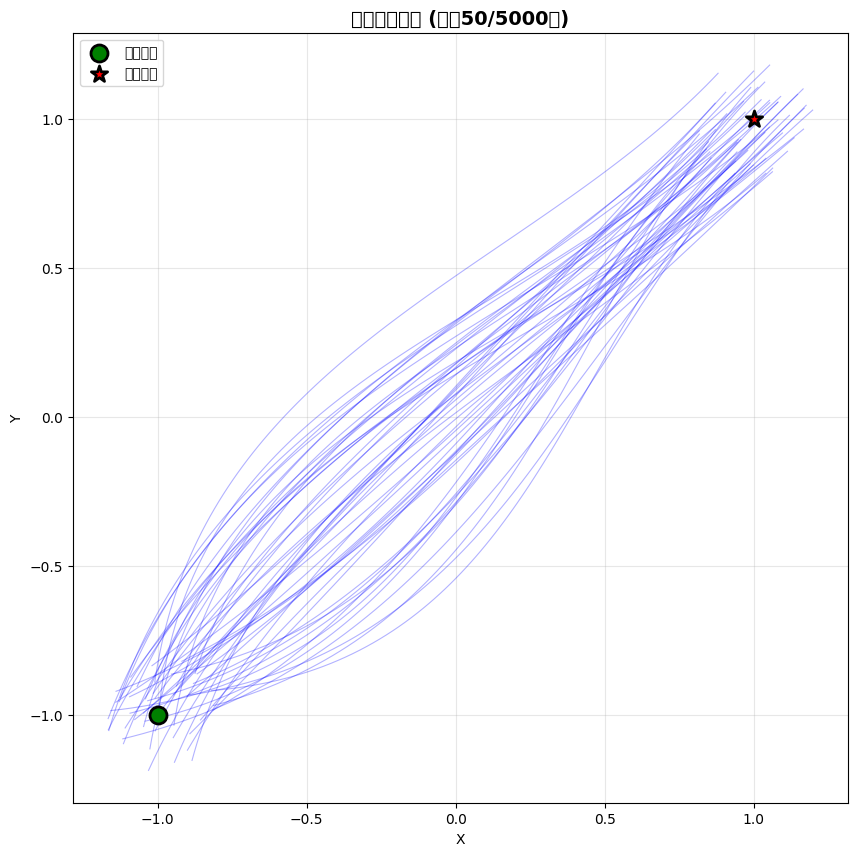

In [62]:
# ===============================================================
# 第一阶段: 生成训练数据
# ===============================================================

class TrajectoryDataset(Dataset):
    def __init__(self, trajectories):
        self.trajectories = trajectories
    
    def __len__(self):
        return len(self.trajectories)
    
    def __getitem__(self, idx):
        return torch.tensor(self.trajectories[idx], dtype=torch.float32)

def sample_point_in_circle(center, radius):
    angle = np.random.uniform(0, 2 * np.pi)
    r = radius * np.sqrt(np.random.uniform(0, 1))
    return center + r * np.array([np.cos(angle), np.sin(angle)])

def generate_bezier_curve(P0, P1, P2, P3, num_points=100):
    P0 = np.asarray(P0, dtype=np.float32)
    P1 = np.asarray(P1, dtype=np.float32)
    P2 = np.asarray(P2, dtype=np.float32)
    P3 = np.asarray(P3, dtype=np.float32)

    t = np.linspace(0, 1, num_points, dtype=np.float32).reshape(-1, 1)
    B_t = (1 - t)**3 * P0 + 3 * (1 - t)**2 * t * P1 \
        + 3 * (1 - t) * t**2 * P2 + t**3 * P3
    return B_t.astype(np.float32)   # 保底再 cast 一次


# 生成训练数据
print("📊 生成Bezier轨迹训练数据...")

baseline_start = np.array([-1, -1])
baseline_end = np.array([1, 1])
radius = 0.2
perturbation_scale_P1 = 0.7
perturbation_scale_P2 = 0.01

num_trajectories = 5000  # 减少到5000条以加快训练
trajectories = []

for i in range(num_trajectories):
    P0 = sample_point_in_circle(baseline_start, radius)
    P3 = sample_point_in_circle(baseline_end, radius)
    
    base_vector = P3 - P0
    perp_vector = np.array([-base_vector[1], base_vector[0]])
    perp_vector = perp_vector / (np.linalg.norm(perp_vector) + 1e-8)
    
    P1 = P0 + base_vector / 3.0 + np.random.uniform(-perturbation_scale_P1, perturbation_scale_P1) * perp_vector
    P2 = P0 + 2 * base_vector / 3.0 + np.random.uniform(-perturbation_scale_P2, perturbation_scale_P2) * perp_vector
    
    curve = generate_bezier_curve(P0, P1, P2, P3, num_points=100)
    trajectories.append(curve.T)  # (2, 100)

trajectories = np.array(trajectories)  # (5000, 2, 100)

print(f"✅ 生成完成: {trajectories.shape}")

# 可视化训练数据样本
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
num_display = 50
for i in range(num_display):
    ax.plot(trajectories[i, 0], trajectories[i, 1], 'b-', alpha=0.3, linewidth=0.8)
ax.scatter(baseline_start[0], baseline_start[1], c='green', s=150, marker='o', 
          edgecolors='black', linewidths=2, zorder=5, label='起点区域')
ax.scatter(baseline_end[0], baseline_end[1], c='red', s=150, marker='*', 
          edgecolors='black', linewidths=2, zorder=5, label='终点区域')
ax.set_title(f'训练数据样本 (显示{num_display}/{num_trajectories}条)', fontsize=14, fontweight='bold')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.axis('equal')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

In [63]:
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 用你刚刚生成好的 trajectories: (num_traj, 2, 100)
dataset = TrajectoryDataset(trajectories)
batch_size = 64
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
print("✅ DataLoader 准备完成")


✅ DataLoader 准备完成


In [65]:
# ===============================================================
# 第三阶段: 初始化 Scene Encoder + 条件版 1D UNet
# ===============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("当前使用设备:", device)

# 超参数
time_emb_dim = 128
hidden_dim   = 128
T_hist       = 8    # history 长度（这里简化用前 8 帧）
in_dim_B     = 4    # 假设 B_history 每帧是 [x_B, y_B, vx_B, vy_B]

# 1) 场景编码器（轻量版 MLP-Mixer）
scene_encoder = SceneEncoderMLPMixer(
    T_hist=T_hist,
    in_dim=in_dim_B,
    hidden_dim=64,
    num_layers=2,
    cond_dim=time_emb_dim,   # 输出维度与 time_emb_dim 对齐
).to(device)

# 2) 条件版 FM 网络（SimpleUNet1D）
fm_model = SimpleUNet1D(
    time_emb_dim=time_emb_dim,
    hidden_dim=hidden_dim,
    cond_dim=time_emb_dim,   # 与 scene_encoder 输出对齐
).to(device)

# 优化器
optimizer = torch.optim.Adam(
    list(fm_model.parameters()) + list(scene_encoder.parameters()),
    lr=1e-3
)

print("✅ SceneEncoder + SimpleUNet1D 初始化完成")


当前使用设备: cuda


AcceleratorError: CUDA error: an illegal instruction was encountered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [66]:
# ===============================================================
# 第四阶段: 构造一个“伪”B_history（从 A 轨迹生成）
# ===============================================================

def build_fake_B_history_from_A(traj_batch: torch.Tensor, T_hist: int = 8) -> torch.Tensor:
    """
    用当前 batch 的 A 轨迹，构造一个假的 B_history:
      输入 traj_batch: (B, 2, T_traj)  -> [x_A, y_A]
      输出 B_history:  (B, T_hist, 4)  -> [x_B, y_B, vx_B, vy_B]
    
    这里简单地取前 T_hist 个点作为 B 的 position，再用差分近似 velocity。
    只是为了让 SceneEncoder 和 conditional FM 先跑通。
    """
    # 取前 T_hist 帧的位置 (B, 2, T_hist)
    pos = traj_batch[:, :, :T_hist]                      # (B, 2, T_hist)
    pos = pos.permute(0, 2, 1)                           # (B, T_hist, 2)

    # 用差分近似速度
    vel = pos[:, 1:, :] - pos[:, :-1, :]                 # (B, T_hist-1, 2)
    # 补一帧，让长度对齐 T_hist
    last_vel = vel[:, -1:, :]                            # (B, 1, 2)
    vel = torch.cat([vel, last_vel], dim=1)              # (B, T_hist, 2)

    # 拼接 -> (B, T_hist, 4)
    B_history = torch.cat([pos, vel], dim=-1)
    return B_history


In [39]:
# ===============================================================
# 第五阶段: 简化 Flow Matching 训练循环
# ===============================================================

num_epochs = 10
print_every = 50

fm_model.train()
scene_encoder.train()

for epoch in range(num_epochs):
    running_loss = 0.0

    for step, batch_traj in enumerate(dataloader):
        # batch_traj: (B, 2, T_traj)
        batch_traj = batch_traj.to(device)         # x0
        B, C, T_traj = batch_traj.shape

        # 1) 构造“伪” B_history 并编码成 cond
        B_history = build_fake_B_history_from_A(batch_traj, T_hist=T_hist)  # (B, T_hist, 4)
        B_history = B_history.to(device)

        cond = scene_encoder(B_history)           # (B, time_emb_dim)

        # 2) Flow Matching 的简化训练目标
        #    采样噪声终点 x1 = eps ~ N(0, I)
        eps = torch.randn_like(batch_traj)        # (B, 2, T_traj)
        x0 = batch_traj                           # (B, 2, T_traj)
        x1 = eps

        # 采样时间 t ~ U(0,1)
        t = torch.rand(B, device=device)          # (B,)
        # reshape 成 (B,1,1) 以便广播
        t_broadcast = t.view(B, 1, 1)

        # 构造中间点 x_t = (1-t)*x0 + t*x1
        x_t = (1.0 - t_broadcast) * x0 + t_broadcast * x1  # (B, 2, T_traj)

        # 真正的目标速度场 v* = dx/dt = x1 - x0  (简化版)
        v_target = x1 - x0                         # (B, 2, T_traj)

        # 3) 前向网络，预测 v_pred
        v_pred = fm_model(x_t, t, cond=cond)       # (B, 2, T_traj)

        # 4) 损失函数：MSE(v_pred, v_target)
        loss = F.mse_loss(v_pred, v_target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if (step + 1) % print_every == 0:
            avg_loss = running_loss / print_every
            print(f"[Epoch {epoch+1}/{num_epochs}] Step {step+1}/{len(dataloader)} | loss = {avg_loss:.6f}")
            running_loss = 0.0

    # 每个 epoch 结束打印一下平均损失（粗略）
    print(f"✅ Epoch {epoch+1} 结束")

print("🎉 训练循环结束（简化 Flow Matching 版本）")


[Epoch 1/10] Step 50/79 | loss = 0.355130
✅ Epoch 1 结束
[Epoch 2/10] Step 50/79 | loss = 0.069892
✅ Epoch 2 结束
[Epoch 3/10] Step 50/79 | loss = 0.050778
✅ Epoch 3 结束
[Epoch 4/10] Step 50/79 | loss = 0.045034
✅ Epoch 4 结束
[Epoch 5/10] Step 50/79 | loss = 0.046585
✅ Epoch 5 结束
[Epoch 6/10] Step 50/79 | loss = 0.035165
✅ Epoch 6 结束
[Epoch 7/10] Step 50/79 | loss = 0.033041
✅ Epoch 7 结束
[Epoch 8/10] Step 50/79 | loss = 0.027192
✅ Epoch 8 结束
[Epoch 9/10] Step 50/79 | loss = 0.027509
✅ Epoch 9 结束
[Epoch 10/10] Step 50/79 | loss = 0.025497
✅ Epoch 10 结束
🎉 训练循环结束（简化 Flow Matching 版本）


In [40]:
# ===============================================================
# 采样函数: 从噪声出发，用训练好的 fm_model 生成一条轨迹
# ===============================================================

def sample_trajectory(fm_model,
                      T_traj: int = 100,
                      n_steps: int = 50,
                      cond: torch.Tensor = None,
                      device: torch.device = torch.device("cpu")) -> np.ndarray:
    """
    从 N(0, I) 噪声出发，沿 Flow Matching 向量场反向积分，生成一条轨迹。
    fm_model: 训练好的 SimpleUNet1D（conditional 版）
    T_traj:   轨迹长度 (与你训练时一致，这里是 100)
    n_steps:  ODE 离散步数（越大越平滑）
    cond:     (1, cond_dim) 条件向量；如果为 None，则用全 0
    返回:      (2, T_traj) 的 numpy 数组
    """
    fm_model.eval()
    with torch.no_grad():
        # 初始状态: 纯噪声 (相当于 t = 1)
        x = torch.randn(1, 2, T_traj, device=device)
        
        # 如果没有提供 cond，就用全 0（先简单验证一下采样效果）
        if cond is None:
            cond = torch.zeros(1, fm_model.time_emb_dim, device=device)

        dt = 1.0 / n_steps

        # 从 t=1 走回 t=0
        for k in range(n_steps, 0, -1):
            t = torch.full((1,), k * dt, device=device)  # t ∈ (0,1]
            v = fm_model(x, t, cond=cond)                # (1, 2, T_traj)
            # 反向积分: x ← x - dt * v
            x = x - dt * v

        traj = x[0].detach().cpu().numpy()   # (2, T_traj)
    return traj

print("✅ sample_trajectory 定义完成")


✅ sample_trajectory 定义完成


In [53]:
# ===============================================================
# 可视化: 采样的轨迹 vs 训练数据的 Bezier 轨迹
# ===============================================================

import matplotlib.pyplot as plt

fm_model.eval()

num_samples = 20
sampled_trajs = []

# 这里先用 cond = 0，等你有真正 B 场景后再换
cond0 = torch.zeros(1, fm_model.time_emb_dim, device=device)

for i in range(num_samples):
    traj_sample = sample_trajectory(fm_model,
                                    T_traj=trajectories.shape[-1],
                                    n_steps=80,
                                    cond=cond0,
                                    device=device)
    sampled_trajs.append(traj_sample)

fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# 画部分真实轨迹
num_display_real = 50
for i in range(num_display_real):
    ax.plot(trajectories[i, 0], trajectories[i, 1],
            'b-', alpha=0.15, linewidth=0.8, label='真实轨迹' if i == 0 else None)

# 画生成轨迹
for i, traj in enumerate(sampled_trajs):
    ax.plot(traj[0], traj[1],
            'r--', alpha=0.7, linewidth=1.0, label='采样轨迹' if i == 0 else None)

ax.scatter(baseline_start[0], baseline_start[1], c='green', s=80, marker='o', label='起点区域')
ax.scatter(baseline_end[0], baseline_end[1], c='red', s=80, marker='*', label='终点区域')

ax.set_title("Flow Matching sampling vs Bezier training data", fontsize=14, fontweight='bold')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.axis('equal')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


AcceleratorError: CUDA error: an illegal instruction was encountered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


📊 生成两车对向 Bezier 轨迹数据...
✅ A_trajs: (5000, 2, 100), B_trajs: (5000, 2, 100)


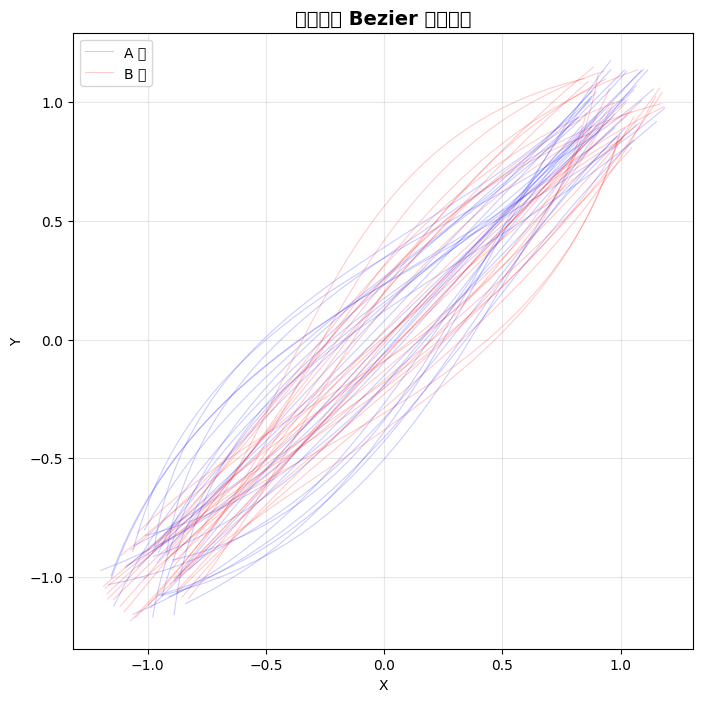

In [ ]:
# ===============================================================
# 生成两车对向 Bezier 轨迹数据: A_traj, B_traj
# ===============================================================

print("📊 生成两车对向 Bezier 轨迹数据...")

num_trajectories = 5000
T_traj = 100

A_trajs = []
B_trajs = []

# A: 左下 → 右上
A_start = np.array([-1.0, 1.0], dtype=np.float32)
A_end   = np.array([ 1.0,  -1.0], dtype=np.float32)

# B: 右下 → 左上（与 A 对向交叉）
B_start = np.array([ 1.0, 1.0], dtype=np.float32)
B_end   = np.array([-1.0, -1.0], dtype=np.float32)

radius_A = 0.2
radius_B = 0.2
perturbation_scale_P1_A = 0.7
perturbation_scale_P2_A = 0.01
perturbation_scale_P1_B = 0.7
perturbation_scale_P2_B = 0.01

for i in range(num_trajectories):
    # ---------- 生成 A 的控制点 ----------
    P0_A = sample_point_in_circle(A_start, radius_A)
    P3_A = sample_point_in_circle(A_end,   radius_A)

    base_vec_A = P3_A - P0_A
    perp_vec_A = np.array([-base_vec_A[1], base_vec_A[0]])
    perp_vec_A = perp_vec_A / (np.linalg.norm(perp_vec_A) + 1e-8)

    P1_A = P0_A + base_vec_A / 3.0  + np.random.uniform(-perturbation_scale_P1_A,
                                                        perturbation_scale_P1_A) * perp_vec_A
    P2_A = P0_A + 2 * base_vec_A / 3.0 + np.random.uniform(-perturbation_scale_P2_A,
                                                           perturbation_scale_P2_A) * perp_vec_A

    curve_A = generate_bezier_curve(P0_A, P1_A, P2_A, P3_A, num_points=T_traj)  # (T, 2)

    # ---------- 生成 B 的控制点 ----------
    P0_B = sample_point_in_circle(B_start, radius_B)
    P3_B = sample_point_in_circle(B_end,   radius_B)

    base_vec_B = P3_B - P0_B
    perp_vec_B = np.array([-base_vec_B[1], base_vec_B[0]])
    perp_vec_B = perp_vec_B / (np.linalg.norm(perp_vec_B) + 1e-8)

    P1_B = P0_B + base_vec_B / 3.0  + np.random.uniform(-perturbation_scale_P1_B,
                                                        perturbation_scale_P1_B) * perp_vec_B
    P2_B = P0_B + 2 * base_vec_B / 3.0 + np.random.uniform(-perturbation_scale_P2_B,
                                                           perturbation_scale_P2_B) * perp_vec_B

    curve_B = generate_bezier_curve(P0_B, P1_B, P2_B, P3_B, num_points=T_traj)  # (T, 2)

    A_trajs.append(curve_A.T)  # (2, T)
    B_trajs.append(curve_B.T)  # (2, T)

A_trajs = np.array(A_trajs, dtype=np.float32)   # (N, 2, T)
B_trajs = np.array(B_trajs, dtype=np.float32)   # (N, 2, T)

print(f"✅ A_trajs: {A_trajs.shape}, B_trajs: {B_trajs.shape}")

# 可视化几条
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
for i in range(30):
    ax.plot(A_trajs[i, 0], A_trajs[i, 1], 'b-', alpha=0.2, linewidth=0.8, label='A 车' if i == 0 else None)
    ax.plot(B_trajs[i, 0], B_trajs[i, 1], 'r-', alpha=0.2, linewidth=0.8, label='B 车' if i == 0 else None)

ax.set_title("两车对向 Bezier 轨迹样本", fontsize=14, fontweight='bold')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.axis('equal')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


In [44]:
# ===============================================================
# Dataset: 返回 (A_traj, B_traj)
# ===============================================================

class ABTrajectoryDataset(Dataset):
    def __init__(self, A_trajs: np.ndarray, B_trajs: np.ndarray):
        """
        A_trajs, B_trajs: (N, 2, T)
        """
        assert A_trajs.shape == B_trajs.shape
        self.A_trajs = A_trajs
        self.B_trajs = B_trajs
    
    def __len__(self):
        return self.A_trajs.shape[0]
    
    def __getitem__(self, idx):
        A = torch.tensor(self.A_trajs[idx], dtype=torch.float32)  # (2, T)
        B = torch.tensor(self.B_trajs[idx], dtype=torch.float32)  # (2, T)
        return A, B

dataset_AB = ABTrajectoryDataset(A_trajs, B_trajs)
batch_size = 64
dataloader_AB = DataLoader(dataset_AB, batch_size=batch_size, shuffle=True, drop_last=True)

print("✅ ABTrajectoryDataset & DataLoader 准备完成")
print("样本数量:", len(dataset_AB))


✅ ABTrajectoryDataset & DataLoader 准备完成
样本数量: 5000


In [45]:
# ===============================================================
# 从 B_traj 构造真正的 B_history: [x_B, y_B, vx_B, vy_B]
# ===============================================================

def build_B_history_from_B(B_traj_batch: torch.Tensor, T_hist: int = 8) -> torch.Tensor:
    """
    B_traj_batch: (B, 2, T_traj)
    返回 B_history: (B, T_hist, 4) = [x_B, y_B, vx_B, vy_B]
    """
    B, C, T_traj = B_traj_batch.shape
    assert C == 2, "B 车轨迹应该是 (2, T)"

    # 位置: 取前 T_hist 帧
    pos = B_traj_batch[:, :, :T_hist]           # (B, 2, T_hist)
    pos = pos.permute(0, 2, 1)                  # (B, T_hist, 2)

    # 速度: 差分
    vel = pos[:, 1:, :] - pos[:, :-1, :]        # (B, T_hist-1, 2)
    last_vel = vel[:, -1:, :]                   # (B, 1, 2)
    vel = torch.cat([vel, last_vel], dim=1)     # (B, T_hist, 2)

    B_history = torch.cat([pos, vel], dim=-1)   # (B, T_hist, 4)
    return B_history


In [46]:
# ===============================================================
# 用 A_traj / B_traj 做条件 Flow Matching 训练
# ===============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("当前使用设备:", device)

time_emb_dim = 128
hidden_dim   = 128
T_hist       = 8
in_dim_B     = 4

scene_encoder = SceneEncoderMLPMixer(
    T_hist=T_hist,
    in_dim=in_dim_B,
    hidden_dim=64,
    num_layers=2,
    cond_dim=time_emb_dim,
).to(device)

fm_model = SimpleUNet1D(
    time_emb_dim=time_emb_dim,
    hidden_dim=hidden_dim,
    cond_dim=time_emb_dim,
).to(device)

optimizer = torch.optim.Adam(
    list(fm_model.parameters()) + list(scene_encoder.parameters()),
    lr=1e-3
)

num_epochs = 10
print_every = 50

fm_model.train()
scene_encoder.train()

for epoch in range(num_epochs):
    running_loss = 0.0

    for step, batch in enumerate(dataloader_AB):
        A_traj, B_traj = batch            # (B, 2, T_traj) x2
        A_traj = A_traj.to(device)
        B_traj = B_traj.to(device)
        B, C, T_traj = A_traj.shape

        # 1) 从 B_traj 构造 B_history -> cond
        B_history = build_B_history_from_B(B_traj, T_hist=T_hist).to(device)  # (B, T_hist, 4)
        cond = scene_encoder(B_history)                                       # (B, time_emb_dim)

        # 2) Flow Matching 目标
        x0 = A_traj
        x1 = torch.randn_like(x0)            # 噪声终点
        t = torch.rand(B, device=device)     # (B,)
        t_broadcast = t.view(B, 1, 1)

        x_t = (1.0 - t_broadcast) * x0 + t_broadcast * x1
        v_target = x1 - x0

        v_pred = fm_model(x_t, t, cond=cond)

        loss = F.mse_loss(v_pred, v_target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if (step + 1) % print_every == 0:
            avg_loss = running_loss / print_every
            print(f"[Epoch {epoch+1}/{num_epochs}] Step {step+1}/{len(dataloader_AB)} | loss = {avg_loss:.6f}")
            running_loss = 0.0

    print(f"✅ Epoch {epoch+1} 结束")

print("🎉 条件 Flow Matching 训练完成（两车对向场景）")


当前使用设备: cuda
[Epoch 1/10] Step 50/78 | loss = 0.370724
✅ Epoch 1 结束
[Epoch 2/10] Step 50/78 | loss = 0.080298
✅ Epoch 2 结束
[Epoch 3/10] Step 50/78 | loss = 0.063127
✅ Epoch 3 结束
[Epoch 4/10] Step 50/78 | loss = 0.056771
✅ Epoch 4 结束
[Epoch 5/10] Step 50/78 | loss = 0.047462
✅ Epoch 5 结束
[Epoch 6/10] Step 50/78 | loss = 0.048456
✅ Epoch 6 结束
[Epoch 7/10] Step 50/78 | loss = 0.046461
✅ Epoch 7 结束
[Epoch 8/10] Step 50/78 | loss = 0.043460
✅ Epoch 8 结束
[Epoch 9/10] Step 50/78 | loss = 0.043594
✅ Epoch 9 结束
[Epoch 10/10] Step 50/78 | loss = 0.041027
✅ Epoch 10 结束
🎉 条件 Flow Matching 训练完成（两车对向场景）


In [47]:
# ===============================================================
# CBF 投影（世界坐标）：整条轨迹版本 + 单步 wrapper
# ===============================================================

@torch.no_grad()
def cbf_project_velocity_world(
    x_1x2N: torch.Tensor,
    v_nom_1x2N: torch.Tensor,
    ellipses,
    extra_margin: float = 0.5,
    max_corr_norm: float = 2.0,
    passes: int = 5,
    # ★ 两车互相避障相关
    other_agent_traj: torch.Tensor = None,   # 允许形状 (1,2,N) 或 (2,N)
    agent_safe_radius: float = 0.5,
    # ★ 压强 + α(h) 参数
    gamma_min: float = 1.0,
    w_p: float = 5.0,
    press_k: float = 1.0,
    press_n: float = 2.0,
):
    """
    CBF 投影（世界坐标，整条轨迹版本）：
      - 对静态椭圆障碍 + 另一辆车，都加 CBF 约束
      - α(h) = γ(x) * h，其中 γ(x) = γ_min + w_p * P(x)，压强 P(x)=k/d^n

    输入:
      - x_1x2N:      (1,2,N) 当前整条轨迹（A 车位置）
      - v_nom_1x2N:  (1,2,N) 名义速度场（FM 输出）
      - ellipses:    障碍物列表（可以为 [] 或 None）
      - other_agent_traj:
            - (1,2,N) 或 (2,N)，另一辆车的整条轨迹（B 车）
    输出:
      - v_safe_1x2N: (1,2,N) 投影后的安全速度
    """
    has_ellipses = (ellipses is not None) and (len(ellipses) > 0)
    has_other = other_agent_traj is not None

    # 如果既没有障碍又没有对车，那就不用 CBF
    if (not has_ellipses) and (not has_other):
        return v_nom_1x2N

    # 允许 x_1x2N 传入 (2,N)，统一成 (1,2,N)
    if x_1x2N.dim() == 2:
        x_1x2N = x_1x2N.unsqueeze(0)
    B, D, N = x_1x2N.shape
    assert D == 2, "x_1x2N 的 shape 必须是 (B,2,N) 或 (2,N)"

    # v_nom 同样统一维度
    if v_nom_1x2N.dim() == 2:
        v_nom_1x2N = v_nom_1x2N.unsqueeze(0)

    # 为了简单，我们目前只支持 B=1 的单条轨迹
    assert B == 1, "当前实现假定 batch=1（单条轨迹），如果需要批量可再扩展"

    x_world_2N = x_1x2N.squeeze(0)  # (2,N)
    v_now = v_nom_1x2N.squeeze(0)   # (2,N)

    # ============================================================
    # 1) 计算两车之间的压强 P(x)
    # ============================================================
    if has_other:
        # 支持 (1,2,N) 或 (2,N)
        if other_agent_traj.dim() == 3:
            x_other_2N = other_agent_traj.squeeze(0)  # (2,N)
        elif other_agent_traj.dim() == 2:
            x_other_2N = other_agent_traj             # (2,N)
        else:
            raise ValueError("other_agent_traj 形状必须是 (1,2,N) 或 (2,N)")

        # delta_agent: (N,2) = x_A - x_B
        delta_agent = x_world_2N.transpose(0, 1) - x_other_2N.transpose(0, 1)  # (N,2)
        dist = torch.norm(delta_agent, dim=1).clamp_min(1e-3)                  # (N,)
        P = press_k / dist.pow(press_n)                                        # (N,)
    else:
        delta_agent = None
        dist = None
        P = torch.zeros(N, device=x_world_2N.device)

    # γ(x) = γ_min + w_p * P
    gamma_x = gamma_min + w_p * P  # (N,)

    # ============================================================
    # 2) CBF 投影主循环（多次迭代 refine）
    # ============================================================
    for _ in range(max(1, passes)):
        all_s = []
        all_a = []

        v_T = v_now.transpose(0, 1)  # (N,2)

        # ---------- (a) 静态椭圆障碍 CBF ----------
        if has_ellipses:
            for e in ellipses:
                # 你之前定义好的函数：ellipse_h_grad_batch(x, e)
                # 返回:
                #   h_e:   (N,)
                #   grad_w:(N,2)
                h_e, grad_w = ellipse_h_grad_batch(x_world_2N, e)
                h_eff = h_e - float(extra_margin)          # 安全 margin

                # α(h) = γ(x) * h
                alpha_h = gamma_x * h_eff                  # (N,)

                # CBF: ∇h·v + α(h) ≥ 0
                s_e = (grad_w * v_T).sum(dim=1) + alpha_h  # (N,)

                all_s.append(s_e)
                all_a.append(grad_w)

        # ---------- (b) 两车之间的 CBF ----------
        if has_other:
            # 注意：delta_agent 和 dist 在上面已经算过
            # h_agent(x) = ||x - x_other||^2 - R_safe^2
            h_agent = dist**2 - agent_safe_radius**2      # (N,)
            grad_agent = 2.0 * delta_agent                # (N,2)

            alpha_h_agent = gamma_x * h_agent             # (N,)
            s_agent = (grad_agent * v_T).sum(dim=1) + alpha_h_agent

            all_s.append(s_agent)
            all_a.append(grad_agent)

        if len(all_s) == 0:
            # 没有任何约束
            break

        S_cat = torch.stack(all_s, dim=0)          # (E,N)
        s_min, idx_min = torch.min(S_cat, dim=0)   # (N,)

        A_cat = torch.stack(all_a, dim=0)          # (E,N,2)
        a_pick = A_cat.gather(
            0,
            idx_min.view(1, -1, 1).expand(1, S_cat.size(1), 2)
        ).squeeze(0)  # (N,2)

        # ---------- 只修正违反约束的点 ----------
        mask = (s_min < 0.0)
        if mask.any():
            a_sq = (a_pick ** 2).sum(dim=1).clamp_min(1e-12)
            coef = torch.zeros_like(s_min)
            coef[mask] = -s_min[mask] / a_sq[mask]     # λ = -s / ||a||^2

            delta = (coef.view(1, -1) * a_pick.transpose(0, 1))  # (2,N)

            if max_corr_norm > 0:
                dnorm = delta.norm(dim=0).clamp_min(1e-12)
                scale = torch.clamp(max_corr_norm / dnorm, max=1.0)
                delta = delta * scale

            v_now = v_now + delta

    return v_now.unsqueeze(0)  # (1,2,N)


# ===============================================================
# 单步版本 wrapper：方便在 rollout 的 for k in range(T) 里调用
# ===============================================================

@torch.no_grad()
def cbf_project_velocity_step(
    x_now_2: torch.Tensor,          # (2,)  当前 A 车位置
    v_nom_2: torch.Tensor,          # (2,)  名义速度
    ellipses,
    other_agent_pos_2: torch.Tensor = None,  # (2,) 当前 B 车位置
    agent_safe_radius: float = 0.5,
    extra_margin: float = 0.5,
    max_corr_norm: float = 2.0,
    gamma_min: float = 1.0,
    w_p: float = 5.0,
    press_k: float = 1.0,
    press_n: float = 2.0,
):
    """
    单步 CBF 投影，专为在线仿真准备：
      输入单个时刻的 x_A, v_nom, x_B
      内部自动扩展成 (1,2,1)，调用上面的 cbf_project_velocity_world。
    """
    device = x_now_2.device
    x_traj = x_now_2.view(1, 2, 1)      # (1,2,1)
    v_traj = v_nom_2.view(1, 2, 1)      # (1,2,1)

    if other_agent_pos_2 is not None:
        other_traj = other_agent_pos_2.view(1, 2, 1)   # (1,2,1)
    else:
        other_traj = None

    v_safe_traj = cbf_project_velocity_world(
        x_traj,
        v_traj,
        ellipses,
        extra_margin=extra_margin,
        max_corr_norm=max_corr_norm,
        passes=5,
        other_agent_traj=other_traj,
        agent_safe_radius=agent_safe_radius,
        gamma_min=gamma_min,
        w_p=w_p,
        press_k=press_k,
        press_n=press_n,
    )  # (1,2,1)

    v_safe_2 = v_safe_traj.squeeze(0).squeeze(-1)  # (2,)
    return v_safe_2


In [48]:
# ===============================================================
# 占位: 用 fm_model 生成 nominal 轨迹 + CBF 在线修正
# ===============================================================

def rollout_with_cbf(fm_model,
                     scene_encoder,
                     B_traj: np.ndarray,
                     x0_A: np.ndarray,
                     T_traj: int = 100,
                     n_steps_fm: int = 50,
                     dt_sim: float = 0.1,
                     device: torch.device = torch.device("cpu")):
    """
    思路:
      1) 给定 B_traj（对向车的已知/预测轨迹），先编码成 cond
      2) 用 Flow Matching 从噪声生成一条 A 的 nominal 轨迹 A_nominal
      3) 在仿真中对每个时间步:
          - 取 A_nominal 的期望速度 v_nom
          - 用 B 当前的状态作为动态障碍
          - 调用你的 cbf_project_velocity_world 做速度投影
          - 积分得到 A_safe 轨迹
    这里先写骨架结构，具体 CBF 你可以直接把原函数粘进来用。
    """
    fm_model.eval()
    scene_encoder.eval()

    with torch.no_grad():
        # 1) B_history -> cond
        B_traj_torch = torch.tensor(B_traj, dtype=torch.float32, device=device).unsqueeze(0)  # (1, 2, T)
        B_history = build_B_history_from_B(B_traj_torch, T_hist=8)                            # (1, 8, 4)
        cond = scene_encoder(B_history)                                                       # (1, time_emb_dim)

        # 2) 用 FM 采样 A 的 nominal 轨迹（和上面 sample_trajectory 类似，只是带 cond）
        A_nominal = sample_trajectory(fm_model,
                                      T_traj=T_traj,
                                      n_steps=n_steps_fm,
                                      cond=cond,
                                      device=device)   # (2, T_traj), numpy

    # 3) 这里是 CBF 仿真骨架（需要你把 cbf_project_velocity_world 塞进来）
        dt_sim = 0.1
        T_traj = A_nominal.shape[1]   # 100

        state_A = x0_A.copy()         # np.array([x0, y0])
        A_safe = [state_A.copy()]

        for k in range(T_traj - 1):
            # 名义速度：用 nominal 轨迹的差分
            v_nom = (A_nominal[:, k+1] - A_nominal[:, k]) / dt_sim   # (2,)

            # 当前 B 车位置
            x_B_k = B_traj[:, k]   # (2,)

            # 转成 tensor，送入 CBF 单步投影
            x_A_t = torch.tensor(state_A, dtype=torch.float32, device=device)
            v_nom_t = torch.tensor(v_nom, dtype=torch.float32, device=device)
            x_B_t = torch.tensor(x_B_k, dtype=torch.float32, device=device)

            v_safe_t = cbf_project_velocity_step(
                x_now_2=x_A_t,
                v_nom_2=v_nom_t,
                ellipses=ellipses,              # 你的静态障碍列表
                other_agent_pos_2=x_B_t,
                agent_safe_radius=0.5,
            )

            v_safe = v_safe_t.cpu().numpy()
            state_A = state_A + v_safe * dt_sim
            A_safe.append(state_A.copy())

        A_safe = np.stack(A_safe, axis=1)   # (2, T_traj)


    print("⚠️ 目前只是 CBF 接口骨架，具体投影还需要你把 cbf_project_velocity_world 接进来。")


In [17]:
# ===============================================================
# 保存 / 加载 Flow Matching 模型的工具函数
# ===============================================================

import torch

def save_model(model, optimizer, epoch, filename="fm_model.pth"):
    ckpt = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "epoch": epoch,
    }
    torch.save(ckpt, filename)
    print(f"💾 模型已保存到 {filename}")


def load_model(model, filename, device):
    ckpt = torch.load(filename, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    print(f"🔄 已成功加载模型参数: {filename}")
    return model


In [49]:
import torch
import torch.nn.functional as F

# 1. 设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. 模型 & 优化器
unet_1d = SimpleUNet1D(time_emb_dim=128, hidden_dim=128).to(device)
optimizer = torch.optim.Adam(unet_1d.parameters(), lr=1e-3)

# 3. Flow Matching 的时间调度 & 路径（你前面已经有 CondOTScheduler / AffinePath 定义）
scheduler = CondOTScheduler()
path = AffinePath(scheduler)

print("✅ UNet & FM Path 初始化完成")

# 4. 训练超参数
num_epochs = 20
log_every = 100

loss_history = []      # ⭐⭐⭐ 一定要先定义这个列表

unet_1d.train()
global_step = 0

for epoch in range(num_epochs):
    for batch_idx, traj_batch in enumerate(dataloader):
        # traj_batch: (B, 2, 100) -> 视作 x_1（“真实轨迹”）
        x1 = traj_batch.to(device)     # (B,2,N)
        B, D, N = x1.shape

        # 1) 采样起点噪声 x0
        x0 = torch.randn_like(x1)      # (B,2,N)

        # 2) 随机时间 t ∈ [0,1]
        t = torch.rand(B, device=device)  # (B,)

        # 3) 沿着线性路径采样 x_t, 以及 dx_t = x1 - x0
        sample = path.sample(x0, x1, t)
        x_t = sample.x_t               # (B,2,N)
        v_target = sample.dx_t         # (B,2,N)，等于 x1 - x0

        # 4) UNet 预测速度
        v_pred = unet_1d(x_t, t)       # (B,2,N)

        # 5) Flow Matching 损失：让 v_pred ≈ v_target
        loss = F.mse_loss(v_pred, v_target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 6) 记录 loss
        loss_history.append(loss.item())
        global_step += 1

        if global_step % log_every == 0:
            print(f"[Epoch {epoch+1}/{num_epochs}] "
                  f"step {global_step:05d} | loss = {loss.item():.6f}")

    print(f"✅ Epoch {epoch+1} 结束, 最后一个 batch loss = {loss.item():.6f}")

print("🎉 Flow Matching 训练阶段完成！")
save_model(unet_1d, optimizer, num_epochs, filename="fm_model.pth")


✅ UNet & FM Path 初始化完成
✅ Epoch 1 结束, 最后一个 batch loss = 0.090650
[Epoch 2/20] step 00100 | loss = 0.105619
✅ Epoch 2 结束, 最后一个 batch loss = 0.077021
[Epoch 3/20] step 00200 | loss = 0.065249
✅ Epoch 3 结束, 最后一个 batch loss = 0.050860
[Epoch 4/20] step 00300 | loss = 0.050758
✅ Epoch 4 结束, 最后一个 batch loss = 0.064417
✅ Epoch 5 结束, 最后一个 batch loss = 0.068954
[Epoch 6/20] step 00400 | loss = 0.048452
✅ Epoch 6 结束, 最后一个 batch loss = 0.048397
[Epoch 7/20] step 00500 | loss = 0.051690
✅ Epoch 7 结束, 最后一个 batch loss = 0.042243
[Epoch 8/20] step 00600 | loss = 0.043476
✅ Epoch 8 结束, 最后一个 batch loss = 0.045051
[Epoch 9/20] step 00700 | loss = 0.053768
✅ Epoch 9 结束, 最后一个 batch loss = 0.039616
✅ Epoch 10 结束, 最后一个 batch loss = 0.034508
[Epoch 11/20] step 00800 | loss = 0.032884
✅ Epoch 11 结束, 最后一个 batch loss = 0.035457
[Epoch 12/20] step 00900 | loss = 0.030922
✅ Epoch 12 结束, 最后一个 batch loss = 0.031036
[Epoch 13/20] step 01000 | loss = 0.038020
✅ Epoch 13 结束, 最后一个 batch loss = 0.028892
[Epoch 14/20] ste

In [67]:
# ===============================================================
# 最终版：FM生成 nominal A + CBF 投影成 A_safe + 可视化
# ===============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

@torch.no_grad()
def rollout_with_cbf(
    fm_model,
    scene_encoder,
    A0_init: np.ndarray,          # (2,) A 车初始点
    B_traj: np.ndarray,           # (2,T)
    ellipses=None,                # 静态障碍物（list），可设为 []
    T_traj: int = 100,
    n_steps_fm: int = 80,
    dt_sim: float = 0.1,
    device=torch.device("cpu"),
):
    """
    最终版 pipeline:
        1) 用 B_traj → B_history → cond 
        2) 用 FM 从噪声采样 nominal A: A_nominal
        3) step-by-step 用 CBF 修正 nominal A 速度，得到安全轨迹 A_safe
        4) 返回 A_nominal 和 A_safe 方便画图
    """

    # --------------------------- 1) B_history -> cond ---------------------------
    fm_model.eval()
    scene_encoder.eval()

    B_traj_torch = torch.tensor(B_traj, dtype=torch.float32, device=device).unsqueeze(0)
    B_history = build_B_history_from_B(B_traj_torch, T_hist=8)
    cond = scene_encoder(B_history)    # (1, time_emb_dim)

    # --------------------------- 2) FM 采样 nominal A --------------------------
    A_nominal = sample_trajectory(
        fm_model,
        T_traj=T_traj,
        n_steps=n_steps_fm,
        cond=cond,
        device=device
    )   # (2,T)

    # --------------------------- 3) CBF step-by-step 投影 -----------------------
    A_safe_list = []
    state_A = A0_init.copy()

    for k in range(T_traj - 1):
        # nominal FM velocity
        v_nom = (A_nominal[:, k+1] - A_nominal[:, k]) / dt_sim     # (2,)

        # 对向车的当前位置
        x_B_k = B_traj[:, k]    # (2,)

        # 转 tensor
        x_A_t = torch.tensor(state_A, dtype=torch.float32, device=device)
        v_nom_t = torch.tensor(v_nom, dtype=torch.float32, device=device)
        x_B_t = torch.tensor(x_B_k, dtype=torch.float32, device=device)

        # 调用 step-CBF
        v_safe_t = cbf_project_velocity_step(
            x_now_2=x_A_t,
            v_nom_2=v_nom_t,
            ellipses=ellipses,
            other_agent_pos_2=x_B_t,
            agent_safe_radius=0.5,
        )  # (2,)

        v_safe = v_safe_t.cpu().numpy()

        # 用安全速度积分
        state_A = state_A + v_safe * dt_sim
        A_safe_list.append(state_A.copy())

    A_safe = np.stack(A_safe_list, axis=1)   # (2, T-1)
    return A_nominal, A_safe


# ===============================================================
# 可视化函数：nominal / safe / 对向车
# ===============================================================

def plot_rollout(A_nominal, A_safe, B_traj, title="FM + CBF avoidance"):
    plt.figure(figsize=(8,8))

    # B 车
    plt.plot(B_traj[0], B_traj[1], 'k--', lw=2, label="B 车对向轨迹")

    # A nominal
    plt.plot(A_nominal[0], A_nominal[1], 'b-', lw=2, alpha=0.7, label="A_nominal（FM生成）")

    # A safe
    plt.plot(A_safe[0], A_safe[1], 'r-', lw=2, alpha=0.9, label="A_safe（FM+CBF）")

    plt.scatter(A_nominal[0,0], A_nominal[1,0], c='green', s=100, label="A 起点")
    plt.scatter(B_traj[0,0], B_traj[1,0], c='orange', s=100, label="B 起点")

    plt.title(title, fontsize=16)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.axis("equal")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

print("✅ rollout_with_cbf & 可视化 准备完成")


✅ rollout_with_cbf & 可视化 准备完成


In [68]:
# 假设你已经有：
# A_trajs, B_trajs   (训练时生成的两车轨迹数据)
# fm_model, scene_encoder (训练后的模型)

idx = 0   # 选一条轨迹做测试
A0 = A_trajs[idx][:,0]   # A 起点 (2,)
B_sample = B_trajs[idx]   # (2,T)

A_nominal, A_safe = rollout_with_cbf(
    fm_model,
    scene_encoder,
    A0_init=A0,
    B_traj=B_sample,
    ellipses=[],      # 如果你有静态障碍写进去
    device=device
)

plot_rollout(A_nominal, A_safe, B_sample)


AcceleratorError: CUDA error: an illegal instruction was encountered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


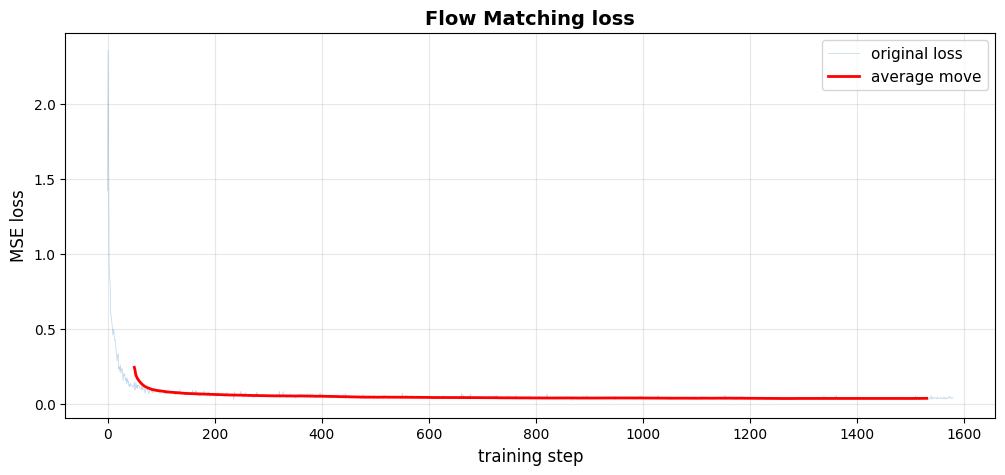

final loss: 0.035432
最后100步平均损失: 0.036670


In [19]:
# 可视化训练损失
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.plot(loss_history, alpha=0.3, label='original loss', linewidth=0.5)

# 移动平均
if len(loss_history) > 100:
    ma = np.convolve(loss_history, np.ones(100)/100, mode='valid')
    ax.plot(range(50, 50+len(ma)), ma, 'r-', linewidth=2, label='average move')

ax.set_xlabel('training step', fontsize=12)
ax.set_ylabel('MSE loss', fontsize=12)
ax.set_title('Flow Matching loss', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.show()

print(f"final loss: {loss_history[-1]:.6f}")
print(f"最后100步平均损失: {np.mean(loss_history[-100:]):.6f}")

In [20]:
@torch.no_grad()
def sample_fm_trajectory_single(
    model,
    start,
    goal,
    obstacles,
    horizon=100,
    device="cpu",
    T_final=1.0,
    add_noise_std=0.0,
    cbf_passes=5,
    cbf_margin=0.5,
    cbf_max_corr_norm=2.0,
    # 两车相关：
    other_agent_traj_np=None,    # (N,2) 或 None
    agent_safe_radius=0.5,
    gamma_min=1.0,
    w_p=5.0,
    press_k=1.0,
    press_n=2.0,
):
    """
    用 Flow Matching + CBF 生成一辆车的轨迹
    - other_agent_traj_np: 另一辆车的轨迹 (N,2)，只用于 CBF / 压强，不参与 FM 模型输入
    """

    model.eval()
    device = torch.device(device)

    # ---------- 1) 初始线性插值轨迹 ----------
    start = np.asarray(start, np.float32).reshape(2)
    goal  = np.asarray(goal,  np.float32).reshape(2)

    t = np.linspace(0.0, 1.0, horizon, dtype=np.float32).reshape(-1, 1)  # (N,1)
    init_curve = (1 - t) * start + t * goal        # (N,2)
    init_curve = init_curve.T                      # (2,N)

    x_init = torch.from_numpy(init_curve).unsqueeze(0).to(device)  # (1,2,N)

    if add_noise_std > 0.0:
        x_init = x_init + add_noise_std * torch.randn_like(x_init)

    # ---------- 2) 构造 other_agent_traj（如果有） ----------
    if other_agent_traj_np is not None:
        other_agent_traj_np = np.asarray(other_agent_traj_np, np.float32)
        assert other_agent_traj_np.shape == (horizon, 2), "other_agent_traj_np 应为 (N,2)"
        other_agent_traj = torch.from_numpy(other_agent_traj_np.T).unsqueeze(0).to(device)  # (1,2,N)
    else:
        other_agent_traj = None

    use_cbf = (obstacles is not None and len(obstacles) > 0) or (other_agent_traj is not None)

    solver = ODESolver(
        model=model,
        traj_len=horizon,
        T_final=T_final,
        use_cbf=use_cbf,
        ellipses=obstacles,
        cbf_passes=cbf_passes,
        cbf_margin=cbf_margin,
        cbf_max_corr_norm=cbf_max_corr_norm,
        solver_method="dopri5",
        solver_tolerance=1e-5,
        other_agent_traj=other_agent_traj,
        agent_safe_radius=agent_safe_radius,
        gamma_min=gamma_min,
        w_p=w_p,
        press_k=press_k,
        press_n=press_n,
    )

    x_final = solver.sample(x_init)           # (1,2,N)
    traj = x_final.squeeze(0).cpu().numpy().T # (N,2)

    return traj



使用设备: cuda
checkpoint keys: dict_keys(['model_state_dict', 'optimizer_state_dict', 'epoch'])
✅ FM 模型加载完成


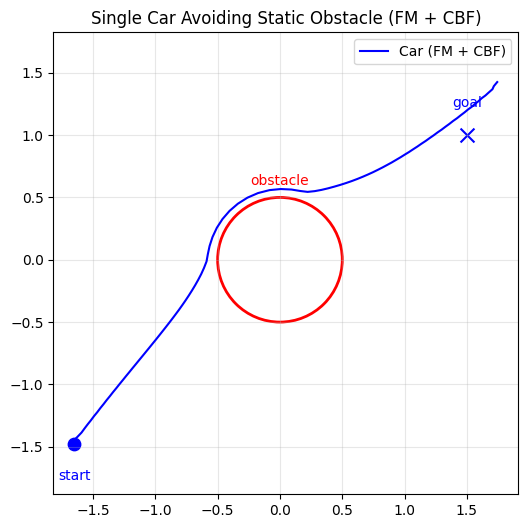

In [21]:
# ============================================
# 单车 + 静态障碍  (包含 model 定义与加载)
# ============================================
import torch
import numpy as np
import matplotlib.pyplot as plt

# 0) 设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("使用设备:", device)

# 1) 定义并加载 FM 模型（确保 SimpleUNet1D 已经在上面定义过）
model = SimpleUNet1D(time_emb_dim=128, hidden_dim=128).to(device)

# 如果你训练时是用 save_model 存的 checkpoint：
ckpt = torch.load("fm_model.pth", map_location=device)
print("checkpoint keys:", ckpt.keys())
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print("✅ FM 模型加载完成")

# 2) 设置静态障碍物
obstacle = {
    "center": np.array([0.0, 0.0], dtype=np.float32),
    "radius": 0.5,
}
obstacles = [obstacle]

# 3) 起点和终点
start_static = [-1.5, -1.0]
goal_static  = [ 1.5,  1.0]

# 4) 用 Flow Matching + CBF 生成单车轨迹（用稍微轻一点的参数，避免卡死）
traj_static = sample_fm_trajectory_single(
    model,
    start=start_static,
    goal=goal_static,
    obstacles=obstacles,      # 有静态障碍
    horizon=100,               # 比 100 更快
    device=device,
    T_final=1,              # 生成时间稍短，形变适中
    add_noise_std=0.0,
    cbf_passes=3,             # CBF 迭代次数减少，提速
    cbf_margin=0.25,
    cbf_max_corr_norm=0,
    other_agent_traj_np=None, # 没有对车
    agent_safe_radius=0.5,
    gamma_min=1.0,
    w_p=0.0,                  # 关闭压强项，只保留静态障碍 CBF
    press_k=1.0,
    press_n=2.0,
)

# 5) 画图
fig, ax = plt.subplots(figsize=(6, 6))

# 轨迹
ax.plot(traj_static[:, 0], traj_static[:, 1], 'b-', label="Car (FM + CBF)")

# === 自动从轨迹中提取真正的起点 ===
start_auto = traj_static[0]   # (x0, y0)
ax.scatter(start_auto[0], start_auto[1], c="blue", marker="o", s=80)
ax.text(start_auto[0], start_auto[1] - 0.2, "start", color="blue",
        ha="center", va="top")


# 终点（用你设的 goal）
ax.scatter(goal_static[0], goal_static[1], c="blue", marker="x", s=100)
ax.text(goal_static[0], goal_static[1] + 0.2, "goal", color="blue",
        ha="center", va="bottom")

# 障碍物
circle = plt.Circle(obstacle["center"], obstacle["radius"],
                    edgecolor="red", facecolor="none", linewidth=2)
ax.add_patch(circle)
ax.text(obstacle["center"][0], obstacle["center"][1] + 0.6,
        "obstacle", color="red", ha="center")

ax.set_title("Single Car Avoiding Static Obstacle (FM + CBF)")
ax.axis("equal")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


In [22]:
def query_local_velocity_from_unet(
    model,
    x_self: torch.Tensor,      # (2,)
    t_scalar: float,
    N_train: int = 100,        # 训练时用的轨迹长度，如果你是 50 就写 50
    device: str = "cpu",
):
    """
    用已经训练好的 UNet-1D，在“伪轨迹”上查询当前点的速度。
    思路：把当前点复制成长度 N_train 的轨迹 -> (1,2,N_train)，
         让 UNet 正常工作，再取最后一个时间步的速度。
    """
    x_self = x_self.to(device)

    # 1) 构造伪轨迹: (1,2,N_train)
    #    (2,) -> (2,1) -> (2,N_train) -> (1,2,N_train)
    x_repeat = x_self.view(2, 1).repeat(1, N_train)  # (2, N_train)
    x_in = x_repeat.unsqueeze(0)                     # (1, 2, N_train)

    # 2) 时间输入（这里先用最简单的，后面你可以换成自己的 time embedding）
    t = torch.tensor([t_scalar], dtype=torch.float32, device=device)  # (1,)

    # 3) 调用 UNet-1D 模型
    #    【⚠️这里按你自己的 forward 来改】
    #    比如如果你的 model.forward 是 forward(x, t_emb)，那就直接用 t
    v_all = model(x_in, t)    # 期望输出 (1,2,N_train)

    # 4) 取最后一个时间步的速度当当前点的速度
    v_nom = v_all[0, :, -1]   # (2,)

    return v_nom


In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

x_test = torch.tensor([0.0, 0.0], device=device)
v_test = query_local_velocity_from_unet(model, x_test, t_scalar=0.5, N_train=100, device=device)
print(v_test.shape, v_test)


torch.Size([2]) tensor([1.6527, 1.4412], device='cuda:0', grad_fn=<SelectBackward0>)


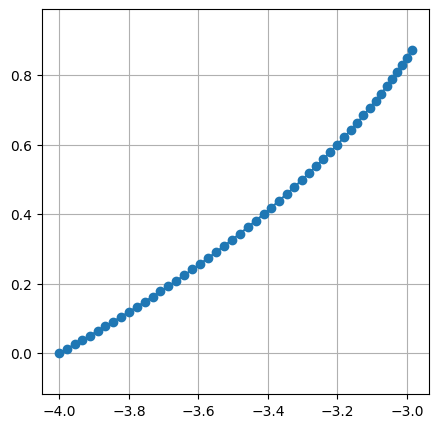

In [24]:
from torchdiffeq import odeint

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# ODE 右端：只是 UNet 给名义速度，还没加 CBF
def fm_ode_func_local(t, x_flat):
    x_self = x_flat.view(2,)      # (2,)
    t_scalar = float(t.item())    # 比如 t 在 [0, 1]
    with torch.no_grad():
        v_nom = query_local_velocity_from_unet(
            model,
            x_self=x_self,
            t_scalar=t_scalar,
            N_train=100,
            device=device,
        )
    return v_nom.view_as(x_flat)

# 初始点
x0 = torch.tensor([-4.0, 0.0], device=device)

# 时间网格
T_final = 1.0
steps   = 50
T_span  = torch.linspace(0.0, T_final, steps, device=device)

sol = odeint(fm_ode_func_local, x0, T_span)  # (steps, 2)

# 画轨迹
import matplotlib.pyplot as plt
sol_np = sol.detach().cpu().numpy()
plt.figure(figsize=(5,5))
plt.plot(sol_np[:,0], sol_np[:,1], '-o')
plt.axis('equal'); plt.grid(True); plt.show()


In [25]:
import torch

def cbf_project_single_point(
    x_self: torch.Tensor,          # (2,)
    v_nom: torch.Tensor,           # (2,)
    ellipses,
    other_agent_pos: torch.Tensor = None,  # (2,) or None
    extra_margin: float = 0.5,
    max_corr_norm: float = 2.0,
    passes: int = 3,
    agent_safe_radius: float = 0.5,
    gamma_min: float = 1.0,
    w_p: float = 5.0,
    press_k: float = 1.0,
    press_n: float = 2.0,
):
    """
    单点版 CBF 投影：
      - x_self: 本车当前位置 (2,)
      - v_nom:  FM 给出的名义速度 (2,)
      - ellipses: 椭圆障碍物列表
      - other_agent_pos: 对车当前位置 (2,) 或 None（没有对车）
    """
    device = x_self.device
    has_ellipses = (ellipses is not None) and (len(ellipses) > 0)
    has_other = other_agent_pos is not None

    if (not has_ellipses) and (not has_other):
        return v_nom

    # 先做成 (2,1) 的“伪轨迹”，方便复用 batch 版本的梯度函数
    x_world_2N = x_self.view(2, 1)      # (2,1)
    v_now      = v_nom.view(2, 1)       # (2,1)

    # ------------------------------
    # 1) 压强 P(x) 来自于对车距离
    # ------------------------------
    if has_other:
        delta_agent = (x_self - other_agent_pos).view(1, 2)  # (1,2)
        dist = torch.norm(delta_agent, dim=1).clamp_min(1e-3)  # (1,)
        P = press_k / dist.pow(press_n)                        # (1,)
    else:
        P = torch.zeros(1, device=device)

    gamma_x = gamma_min + w_p * P  # (1,)

    # ------------------------------
    # 2) CBF 投影迭代（小次数）
    # ------------------------------
    for _ in range(max(1, passes)):
        all_s = []
        all_a = []

        v_T = v_now.transpose(0, 1)  # (1,2)

        # (a) 静态椭圆障碍
        if has_ellipses:
            for e in ellipses:
                # 这里复用你原来的 ellipse_h_grad_batch
                h_e, grad_w = ellipse_h_grad_batch(x_world_2N, e)  # h: (1,), grad: (1,2)
                h_eff = h_e - float(extra_margin)

                alpha_h = gamma_x * h_eff      # (1,)
                s_e = (grad_w * v_T).sum(dim=1) + alpha_h  # (1,)

                all_s.append(s_e)   # 每个都是 (1,)
                all_a.append(grad_w)  # 每个都是 (1,2)

        # (b) 车车之间的 CBF
        if has_other:
            # h_agent = ||x - x_other||^2 - R^2
            h_agent = dist**2 - agent_safe_radius**2        # (1,)
            grad_agent = 2.0 * delta_agent                  # (1,2)

            alpha_h_agent = gamma_x * h_agent
            s_agent = (grad_agent * v_T).sum(dim=1) + alpha_h_agent

            all_s.append(s_agent)
            all_a.append(grad_agent)

        if len(all_s) == 0:
            break

        S_cat = torch.cat(all_s, dim=0)     # (E,)
        A_cat = torch.cat(all_a, dim=0)     # (E,2)

        # 找出最危险（s 最小）的那条约束
        s_min, idx_min = torch.min(S_cat, dim=0)   # (), scalar
        a_pick = A_cat[idx_min]                    # (2,)

        if s_min < 0.0:
            a_sq = (a_pick ** 2).sum().clamp_min(1e-12)
            coef = -s_min / a_sq                   # λ = -s / ||a||^2

            delta = coef * a_pick.view(2, 1)       # (2,1)

            if max_corr_norm > 0:
                dnorm = delta.norm().clamp_min(1e-12)
                scale = torch.clamp(max_corr_norm / dnorm, max=1.0)
                delta = delta * scale

            v_now = v_now + delta  # (2,1)

    return v_now.view(2,)  # 回到 (2,)


In [26]:
def _fm_ode_func_local(self, t, x_2d_flat):
    """
    ODE 右端：
      dx/dt = CBF(UNet(x,t))
    """
    device = x_2d_flat.device
    x_self = x_2d_flat.view(2,)  # 当前状态

    # 把时间归一化到 [0,1]
    t_scalar = float(t.item())

    # --- Step 1: UNet 给名义速度 ---
    with torch.no_grad():
        v_nom = query_local_velocity_from_unet(
            model=self.model,
            x_self=x_self,
            t_scalar=t_scalar,
            N_train=100,    # 训练用的轨迹长度
            device=device,
        )

    # --- Step 2: 压强 CBF 修正 ---
    v_safe = cbf_project_single_point(
        x_self=x_self, 
        v_nom=v_nom,
        ellipses=self.ellipses,     # 静态障碍
        other_agent_pos=None,       # 先单车
        extra_margin=0.5,
        agent_safe_radius=0.5,
        gamma_min=1.0,
        w_p=5.0,
        press_k=1.0,
        press_n=2.0,
    )

    return v_safe.view_as(x_2d_flat)


In [27]:
from torchdiffeq import odeint

def sample_safe_fm_trajectory(
    model,
    start: torch.Tensor,
    ellipses,
    T_final: float = 1.0,
    steps: int = 100,
    N_train: int = 100,
    device: str = "cpu",
):
    """
    用 ODEint 积分生成单车 SafeFlow 轨迹:
        dx/dt = CBF( UNet(x, t) )
    这里是函数形式，不挂在 model 上。
    """
    device = device or start.device
    start = start.to(device).view(2,)   # (2,)

    # --------- 定义 ODE 右端：f(t, x) ---------
    def fm_ode_func_local(t, x_2d_flat):
        x_self = x_2d_flat.view(2,)     # 当前状态 (2,)
        t_scalar = float(t.item())      # 标量时间

        # 1) UNet 给名义速度
        with torch.no_grad():
            v_nom = query_local_velocity_from_unet(
                model=model,
                x_self=x_self,
                t_scalar=t_scalar,
                N_train=N_train,
                device=device,
            )

        # 2) CBF 单点投影（压强版）
        v_safe = cbf_project_single_point(
            x_self=x_self,
            v_nom=v_nom,
            ellipses=ellipses,
            other_agent_pos=None,     # 先单车
            extra_margin=0.5,
            agent_safe_radius=0.5,
            gamma_min=1.0,
            w_p=5.0,
            press_k=1.0,
            press_n=2.0,
        )

        return v_safe.view_as(x_2d_flat)

    # --------- 调用 odeint 积分 ---------
    T_span = torch.linspace(0.0, T_final, steps, device=device)  # (steps,)
    sol = odeint(fm_ode_func_local, start, T_span)               # (steps,2)

    return sol


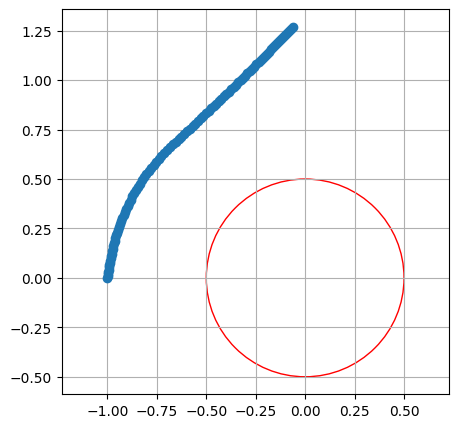

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

ellipses = [
    {"center": np.array([0.0, 0.0]), "radius": 0.5},
]

traj = sample_safe_fm_trajectory(
    model,
    start=torch.tensor([-1.0, 0.0], device=device),
    ellipses=ellipses,
    T_final=1.0,
    steps=100,
    N_train=100,
    device=device,
)

traj_np = traj.detach().cpu().numpy()
plt.figure(figsize=(5,5))
plt.plot(traj_np[:,0], traj_np[:,1], '-o')
for e in ellipses:
    circle = plt.Circle(e["center"], e["radius"], edgecolor='r', facecolor='none')
    plt.gca().add_patch(circle)
plt.axis('equal'); plt.grid(True); plt.show()


In [29]:
def _two_car_ode_func(self, t, state_4d):
    """
    状态 state: (4,) = [xA_x, xA_y, xB_x, xB_y]
    返回 dx/dt : (4,)
    """
    device = state_4d.device

    # --- 分拆 A, B 的坐标 ---
    xA = state_4d[0:2]  # (2,)
    xB = state_4d[2:4]  # (2,)

    t_scalar = float(t.item())

    # --- UNet 给名义速度 ---
    with torch.no_grad():
        vA_nom = query_local_velocity_from_unet(
            self.model, xA, t_scalar, N_train=100, device=device
        )
        vB_nom = query_local_velocity_from_unet(
            self.model, xB, t_scalar, N_train=100, device=device
        )

    # --- 压强 CBF 修正（双向） ---
    vA_safe = cbf_project_single_point(
        x_self=xA,
        v_nom=vA_nom,
        ellipses=self.ellipses,
        other_agent_pos=xB,    # 对车
        extra_margin=0.5,
        agent_safe_radius=0.5,
        gamma_min=1.0,
        w_p=5.0,
        press_k=1.0,
        press_n=2.0,
    )

    vB_safe = cbf_project_single_point(
        x_self=xB,
        v_nom=vB_nom,
        ellipses=self.ellipses,
        other_agent_pos=xA,    # 对车
        extra_margin=0.5,
        agent_safe_radius=0.5,
        gamma_min=1.0,
        w_p=5.0,
        press_k=1.0,
        press_n=2.0,
    )

    # --- 拼回 (4,) ---
    dxdt = torch.zeros_like(state_4d)
    dxdt[0:2] = vA_safe
    dxdt[2:4] = vB_safe
    return dxdt


In [30]:
def sample_two_car_trajectory(self, start_A, start_B, T_final=1.0, steps=200):
    device = start_A.device

    # 初始 4 维状态
    state0 = torch.tensor([
        start_A[0], start_A[1],
        start_B[0], start_B[1],
    ], dtype=torch.float32, device=device)

    T_span = torch.linspace(0, T_final, steps, device=device)

    sol = odeint(self._two_car_ode_func, state0, T_span)  # (steps,4)

    traj_A = sol[:, 0:2]  # (steps,2)
    traj_B = sol[:, 2:4]  # (steps,2)
    return traj_A, traj_B


In [31]:
from torchdiffeq import odeint

def sample_two_car_trajectory(
    model,
    start_A,
    start_B,
    ellipses,
    T_final: float = 4.0,
    steps: int = 400,
    N_train: int = 100,
    device: str = "cpu",
):
    """
    两车轨迹采样（独立函数版本）：
        state = [xA_x, xA_y, xB_x, xB_y]
        dx/dt = CBF( UNet(x,t) )  双向耦合
    """
    device = device or start_A.device

    start_A = start_A.to(device).view(2,)
    start_B = start_B.to(device).view(2,)

    # 初始 4 维状态
    state0 = torch.tensor(
        [start_A[0], start_A[1], start_B[0], start_B[1]],
        dtype=torch.float32,
        device=device,
    )

    # 时间网格
    T_span = torch.linspace(0.0, T_final, steps, device=device)  # (steps,)

    # --------- 内部定义 ODE 右端：f(t, state) ---------
    def two_car_ode_func(t, state_4d):
        """
        state_4d: (4,) = [xA_x, xA_y, xB_x, xB_y]
        返回 dx/dt: (4,)
        """
        xA = state_4d[0:2]   # (2,)
        xB = state_4d[2:4]   # (2,)

        t_scalar = float(t.item())

        # --- UNet 给名义速度 ---
        with torch.no_grad():
            vA_nom = query_local_velocity_from_unet(
                model=model,
                x_self=xA,
                t_scalar=t_scalar,
                N_train=N_train,
                device=device,
            )
            vB_nom = query_local_velocity_from_unet(
                model=model,
                x_self=xB,
                t_scalar=t_scalar,
                N_train=N_train,
                device=device,
            )

        # --- 压强 CBF 修正（双向） ---
        vA_safe = cbf_project_single_point(
            x_self=xA,
            v_nom=vA_nom,
            ellipses=ellipses,
            other_agent_pos=xB,    # 把 B 当动态障碍
            extra_margin=0.5,
            agent_safe_radius=0.5,
            gamma_min=1.0,
            w_p=5.0,
            press_k=1.0,
            press_n=2.0,
        )

        vB_safe = cbf_project_single_point(
            x_self=xB,
            v_nom=vB_nom,
            ellipses=ellipses,
            other_agent_pos=xA,    # 把 A 当动态障碍
            extra_margin=0.5,
            agent_safe_radius=0.5,
            gamma_min=1.0,
            w_p=5.0,
            press_k=1.0,
            press_n=2.0,
        )

        dxdt = torch.zeros_like(state_4d)
        dxdt[0:2] = vA_safe
        dxdt[2:4] = vB_safe
        return dxdt

    # --------- 调用 odeint ---------
    sol = odeint(two_car_ode_func, state0, T_span)  # (steps,4)

    traj_A = sol[:, 0:2]  # (steps,2)
    traj_B = sol[:, 2:4]  # (steps,2)
    return traj_A, traj_B


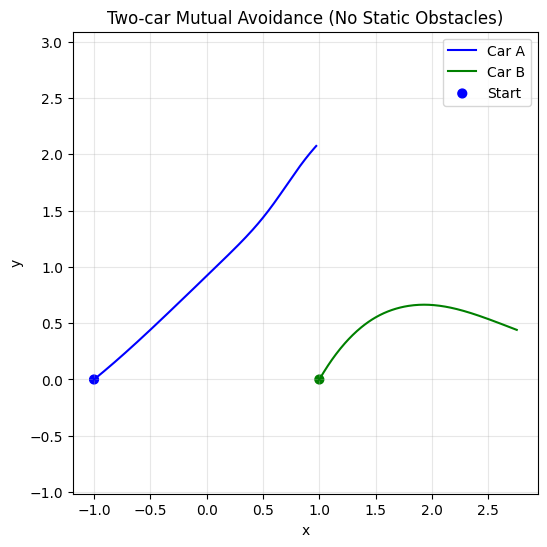

In [32]:
import matplotlib.pyplot as plt
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 1. 不要障碍物
ellipses = []   # 👈 关键：空列表

# 2. 两车起点
start_A = torch.tensor([-1.0, 0.0], dtype=torch.float32, device=device)
start_B = torch.tensor([ 1.0, 0.0], dtype=torch.float32, device=device)

T_final = 2.0
steps   = 200

with torch.no_grad():
    traj_A, traj_B = sample_two_car_trajectory(
        model=model,
        start_A=start_A,
        start_B=start_B,
        ellipses=ellipses,   # 空的，只做两车互相避障
        T_final=T_final,
        steps=steps,
        N_train=100,
        device=device,
    )

# 3. 画图
traj_A_np = traj_A.detach().cpu().numpy()
traj_B_np = traj_B.detach().cpu().numpy()

plt.figure(figsize=(6, 6))
ax = plt.gca()

# 没有障碍物，这里就不画 circle 了

plt.plot(traj_A_np[:, 0], traj_A_np[:, 1], 'b-', label="Car A")
plt.plot(traj_B_np[:, 0], traj_B_np[:, 1], 'g-', label="Car B")

plt.scatter([start_A[0].item(), start_B[0].item()],
            [start_A[1].item(), start_B[1].item()],
            c=['blue', 'green'], marker='o', s=40, label="Start")

plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Two-car Mutual Avoidance (No Static Obstacles)")
plt.show()


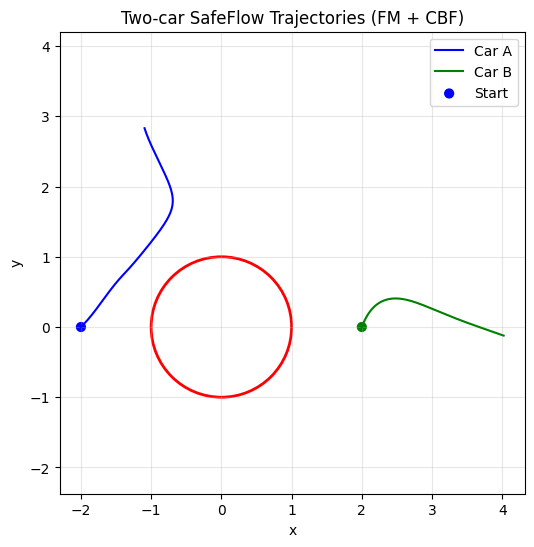

In [33]:
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 1. 定义障碍
ellipses = [
    {"center": np.array([0.0, 0.0]), "radius": 1.0},  # 中间一个圆形障碍
]

# 2. 设置两车起点
start_A = torch.tensor([-2.0, 0.0], dtype=torch.float32, device=device)
start_B = torch.tensor([ 2.0, 0.0], dtype=torch.float32, device=device)

T_final = 4.0
steps   = 400

with torch.no_grad():
    traj_A, traj_B = sample_two_car_trajectory(
        model=model,
        start_A=start_A,
        start_B=start_B,
        ellipses=ellipses,
        T_final=T_final,
        steps=steps,
        N_train=100,
        device=device,
    )

# 3. 画轨迹 + 障碍
traj_A_np = traj_A.detach().cpu().numpy()
traj_B_np = traj_B.detach().cpu().numpy()

plt.figure(figsize=(6, 6))
ax = plt.gca()

# 画障碍
for e in ellipses:
    cx, cy = e["center"]
    r = e["radius"]
    circle = plt.Circle((cx, cy), r, edgecolor="red", facecolor="none", linewidth=2)
    ax.add_patch(circle)

# 画两车轨迹
plt.plot(traj_A_np[:, 0], traj_A_np[:, 1], 'b-', label="Car A")
plt.plot(traj_B_np[:, 0], traj_B_np[:, 1], 'g-', label="Car B")

# 起点标一下
plt.scatter([start_A[0].item(), start_B[0].item()],
            [start_A[1].item(), start_B[1].item()],
            c=['blue', 'green'], marker='o', s=40, label="Start")

plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Two-car SafeFlow Trajectories (FM + CBF)")
plt.show()


In [34]:
from torchdiffeq import odeint

def sample_two_car_trajectory(
    model,
    start_A,
    start_B,
    goal_A,
    goal_B,
    ellipses,
    T_final: float = 4.0,
    steps: int = 400,
    N_train: int = 100,
    k_goal: float = 5.0,      # 追 goal 的力度
    device: str = "cpu",
):
    """
    两车轨迹采样（独立函数版本 + 目标点）：
        state = [xA_x, xA_y, xB_x, xB_y]
        dx/dt = CBF( UNet(x,t) + v_goal(x, goal) )
    """
    device = device or start_A.device

    start_A = start_A.to(device).view(2,)
    start_B = start_B.to(device).view(2,)
    goal_A  = goal_A.to(device).view(2,)
    goal_B  = goal_B.to(device).view(2,)

    # 初始 4 维状态
    state0 = torch.tensor(
        [start_A[0], start_A[1], start_B[0], start_B[1]],
        dtype=torch.float32,
        device=device,
    )

    # 时间网格
    T_span = torch.linspace(0.0, T_final, steps, device=device)  # (steps,)

    def two_car_ode_func(t, state_4d):
        """
        state_4d: (4,) = [xA_x, xA_y, xB_x, xB_y]
        返回 dx/dt: (4,)
        """
        xA = state_4d[0:2]   # (2,)
        xB = state_4d[2:4]   # (2,)

        t_scalar = float(t.item())

        # --- UNet 给名义速度 ---
        with torch.no_grad():
            vA_fm = query_local_velocity_from_unet(
                model=model,
                x_self=xA,
                t_scalar=t_scalar,
                N_train=N_train,
                device=device,
            )
            vB_fm = query_local_velocity_from_unet(
                model=model,
                x_self=xB,
                t_scalar=t_scalar,
                N_train=N_train,
                device=device,
            )

        # --- 朝各自 goal 的吸引速度（单位方向 * k_goal）---
        def goal_vel(x, g):
            d = g - x
            dist = torch.norm(d).clamp_min(1e-3)
            return k_goal * d / dist

        vA_goal = goal_vel(xA, goal_A)
        vB_goal = goal_vel(xB, goal_B)

        # FM + goal 合成名义速度
        vA_nom = vA_fm + vA_goal
        vB_nom = vB_fm + vB_goal

        # --- 压强 CBF 修正（双向），压强变弱 ---
        vA_safe = cbf_project_single_point(
            x_self=xA,
            v_nom=vA_nom,
            ellipses=ellipses,
            other_agent_pos=xB,    # 把 B 当动态障碍
            extra_margin=0.5,
            agent_safe_radius=0.5,
            gamma_min=1.0,
            w_p=2.0,        # 之前是 5.0 → 压强整体弱一些
            press_k=0.5,     # 之前是 1.0 → 距离相关项也弱一点
            press_n=2.0,
        )

        vB_safe = cbf_project_single_point(
            x_self=xB,
            v_nom=vB_nom,
            ellipses=ellipses,
            other_agent_pos=xA,    # 把 A 当动态障碍
            extra_margin=0.5,
            agent_safe_radius=0.5,
            gamma_min=1.0,
            w_p=2.0,
            press_k=0.5,
            press_n=2.0,
        )

        dxdt = torch.zeros_like(state_4d)
        dxdt[0:2] = vA_safe
        dxdt[2:4] = vB_safe
        return dxdt

    sol = odeint(two_car_ode_func, state0, T_span)  # (steps,4)

    traj_A = sol[:, 0:2]  # (steps,2)
    traj_B = sol[:, 2:4]  # (steps,2)
    return traj_A, traj_B


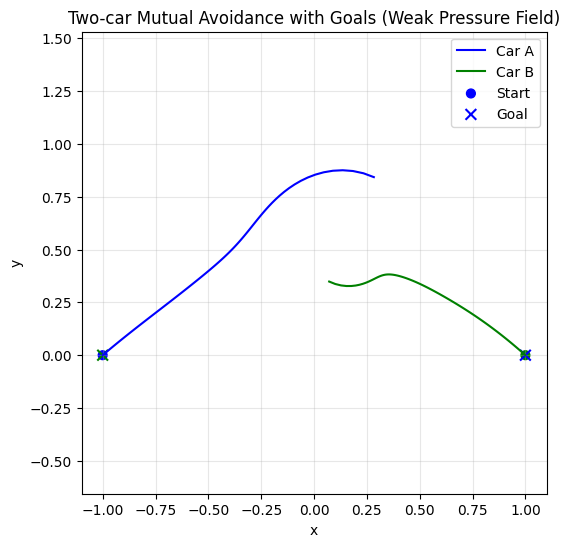

In [35]:
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 1. 不要障碍物
ellipses = []   # 👈 只开车车互相避障

# 2. 起点 & 终点
start_A = torch.tensor([-1.0, 0.0], dtype=torch.float32, device=device)
goal_A  = torch.tensor([ 1.0, 0.0], dtype=torch.float32, device=device)

start_B = torch.tensor([ 1.0, 0.0], dtype=torch.float32, device=device)
goal_B  = torch.tensor([-1.0, 0.0], dtype=torch.float32, device=device)

T_final = 1.0
steps   = 100

with torch.no_grad():
    traj_A, traj_B = sample_two_car_trajectory(
        model=model,
        start_A=start_A,
        start_B=start_B,
        goal_A=goal_A,
        goal_B=goal_B,
        ellipses=ellipses,   # 空列表
        T_final=T_final,
        steps=steps,
        N_train=100,
        k_goal=5.0,          # 追目标的力度，可以之后再调
        device=device,
    )

traj_A_np = traj_A.detach().cpu().numpy()
traj_B_np = traj_B.detach().cpu().numpy()

plt.figure(figsize=(6, 6))
ax = plt.gca()

# 画两车轨迹
plt.plot(traj_A_np[:, 0], traj_A_np[:, 1], 'b-', label="Car A")
plt.plot(traj_B_np[:, 0], traj_B_np[:, 1], 'g-', label="Car B")

# 起点 & 终点
plt.scatter([start_A[0].item(), start_B[0].item()],
            [start_A[1].item(), start_B[1].item()],
            c=['blue', 'green'], marker='o', s=40, label="Start")

plt.scatter([goal_A[0].item(), goal_B[0].item()],
            [goal_A[1].item(), goal_B[1].item()],
            c=['blue', 'green'], marker='x', s=60, label="Goal")

plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Two-car Mutual Avoidance with Goals (Weak Pressure Field)")
plt.show()


In [36]:
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 1. 不要障碍物
ellipses = []   # 👈 只开车车互相避障

# 2. 起点 & 终点
start_A = torch.tensor([-1.0, 0.0], dtype=torch.float32, device=device)
goal_A  = torch.tensor([ 1.0, 0.0], dtype=torch.float32, device=device)

start_B = torch.tensor([ 1.0, 0.0], dtype=torch.float32, device=device)
goal_B  = torch.tensor([-1.0, 0.0], dtype=torch.float32, device=device)

T_final = 2.0
steps   = 200

with torch.no_grad():
    traj_A, traj_B = sample_two_car_trajectory(
        model=model,
        start_A=start_A,
        start_B=start_B,
        goal_A=goal_A,
        goal_B=goal_B,
        ellipses=ellipses,   # 空列表
        T_final=T_final,
        steps=steps,
        N_train=100,
        k_goal=5.0,          # 追目标的力度，可以之后再调
        device=device,
    )

traj_A_np = traj_A.detach().cpu().numpy()
traj_B_np = traj_B.detach().cpu().numpy()

plt.figure(figsize=(6, 6))
ax = plt.gca()

# 画两车轨迹
plt.plot(traj_A_np[:, 0], traj_A_np[:, 1], 'b-', label="Car A")
plt.plot(traj_B_np[:, 0], traj_B_np[:, 1], 'g-', label="Car B")

# 起点 & 终点
plt.scatter([start_A[0].item(), start_B[0].item()],
            [start_A[1].item(), start_B[1].item()],
            c=['blue', 'green'], marker='o', s=40, label="Start")

plt.scatter([goal_A[0].item(), goal_B[0].item()],
            [goal_A[1].item(), goal_B[1].item()],
            c=['blue', 'green'], marker='x', s=60, label="Goal")

plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Two-car Mutual Avoidance with Goals (Weak Pressure Field)")
plt.show()


KeyboardInterrupt: 